# 02-11 Enhanced PESE-guided 3DFF-Net IPH + PHE 2.5D Segmentation (Local, Train-Heavy)

This notebook is the successor to `02-10b`, targeting maximum PHE segmentation performance.

It keeps the project identity: **3DFF-Net = 2.5D segmentation with 3D feature fusion**.

**Key improvements over 02-10b:**

1. **ResNet34** encoder (deeper capacity for diffuse PHE boundaries)
2. **Deep supervision** at multiple decoder levels
3. **Lovász-Softmax loss** for direct IoU/Dice optimization
4. **Stronger data augmentation** (elastic, scale, blur, cutout, brightness)
5. **Cosine annealing scheduler** with warm restarts + linear warmup
6. **Multi-scale test-time augmentation** (0.9×, 1.0×, 1.1×)
7. **Boundary-aware PHE post-processing** (IPH proximity, z-consistency, morphological)
8. **Train-heavy split 99/10/11** for maximum training data

**Optimization pass applied:** reduced over-segmentation risk by softening PHE post-processing, making cutout target-aware, and increasing volume/RVD pressure during threshold tuning.


## 0. Dependency notes


In [1]:
INSTALL_BASIC_DEPS = False

if INSTALL_BASIC_DEPS:
    import sys
    import subprocess
    pkgs = ["numpy", "pandas", "matplotlib", "scipy", "nibabel", "tqdm", "torch", "torchvision"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])


## 1. Configuration (local paths, train-heavy split)


In [2]:
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, Sequence, Tuple


@dataclass
class ThreeDFFConfig:
    project_root: Path = Path.cwd()
    seed: int = 42

    # Run switches.
    run_phe_pretraining: bool = True
    run_training: bool = True
    run_final_eval: bool = True
    debug_small_run: bool = False
    debug_train_cases: int = 8
    debug_val_cases: int = 4
    debug_test_cases: int = 4
    debug_epochs: int = 2

    # 2.5D input: keep 512/triple-window so this stays 3DFF-Net, not full 3D nnU-Net.
    image_size: int = 512
    slice_offsets: tuple = (-2, -1, 0, 1, 2)
    ct_windows: tuple = (
        (-20.0, 100.0),   # brain / edema window
        (-50.0, 150.0),   # blood-sensitive window
        (0.0, 600.0),     # wide tissue/bone context
    )

    # Patient split. Train-heavy split uses more training cases for maximum performance.
    split_strategy: str = "paper_train_heavy"  # train-heavy 99/10/11 for max performance
    paper_train_cases: int = 99
    paper_val_cases: int = 10
    paper_test_cases: int = 11

    # Optional real IPH masks. Keep None when only PHE masks are available.
    true_iph_mask_dir: Optional[str] = None

    # Paper-guided pseudo IPH generation.
    pseudo_generation_mode: str = "paper_hybrid"  # paper_hybrid or seed_grow
    pseudo_seed_hu_low: float = 55.0
    pseudo_seed_hu_high: float = 80.0
    pseudo_grow_hu_low: float = 40.0
    pseudo_grow_hu_high: float = 80.0
    pseudo_fixed_hu_threshold: float = 55.0
    pseudo_otsu_hu_low: float = 40.0
    pseudo_otsu_hu_high: float = 80.0
    pseudo_otsu_bins: int = 128
    pseudo_seed_roi_mm: float = 6.0
    pseudo_grow_roi_mm: float = 12.0
    pseudo_contact_mm: float = 4.0
    pseudo_bbox_margin_mm: float = 28.0
    pseudo_z_margin_slices: int = 2
    pseudo_min_component_ml: float = 0.03
    pseudo_max_component_ml: float = 80.0
    pseudo_max_components: int = 3
    pseudo_min_seed_voxels: int = 3
    pseudo_min_mean_hu: float = 44.0
    pseudo_max_long_axis_mm: float = 75.0
    pseudo_min_extent_large_component: float = 0.012
    pseudo_remove_phe_overlap: bool = True
    pseudo_fill_holes: bool = True
    pseudo_use_brain_mask: bool = True
    pseudo_morph_close_px: int = 5
    pseudo_morph_open_px: int = 3

    # PESE-inspired slice-prior for 3DFF fusion. This stays 2.5D: it only guides
    # how neighboring slice features are weighted before center-slice prediction.
    use_pese_guided_fusion: bool = True
    pese_blood_window_index: int = 1
    pese_blood_threshold_hu: float = 55.0
    pese_prior_strength: float = 0.60
    pese_prior_uniform_blend: float = 0.05
    pese_min_high_hu_pixels: int = 8
    pese_similarity_eps: float = 1e-5

    # Architecture.
    backbone: str = "resnet34"
    pretrained_backbone: bool = True
    fpn_channels: int = 128
    decoder_channels: tuple = (128, 96, 64, 48)
    num_classes: int = 3

    # Stage 1: PHE-only pretraining.
    phe_pretrain_epochs: int = 45
    phe_pretrain_patience: int = 10
    phe_pretrain_freeze_backbone_epochs: int = 1
    phe_pretrain_lr_backbone: float = 1e-5
    phe_pretrain_lr_head: float = 7e-5
    phe_pretrain_positive_slice_weight: float = 4.0
    phe_pretrain_lambda_ce: float = 0.8
    phe_pretrain_lambda_dice: float = 1.2
    phe_pretrain_lambda_boundary: float = 0.03
    phe_pretrain_lambda_tversky: float = 0.30
    joint_init_from_phe_pretrain: bool = True

    # Stage 2: joint IPH/PHE fine-tuning.
    epochs: int = 120
    batch_size: int = 2
    grad_accum_steps: int = 2
    lr_backbone: float = 8e-6
    lr_head: float = 5e-5
    weight_decay: float = 1e-4
    patience: int = 20
    min_delta: float = 1e-4
    freeze_backbone_epochs: int = 1
    amp: bool = True
    num_workers: int = 0
    augment_train: bool = True
    positive_slice_weight: float = 3.0
    lambda_ce: float = 1.0
    lambda_dice: float = 0.7
    lambda_boundary: float = 0.02
    lambda_phe_tversky: float = 0.25
    phe_tversky_alpha: float = 0.40
    phe_tversky_beta: float = 0.60
    joint_val_phe_weight: float = 0.65
    class_weight_min: float = 0.05
    class_weight_max: float = 8.0
    background_weight_cap: float = 0.30


    # Deep supervision.
    use_deep_supervision: bool = True
    ds_weights: tuple = (0.4, 0.2, 0.1)

    # Lovász-Softmax loss.
    lambda_lovasz: float = 0.5

    # Cosine annealing scheduler with warmup.
    use_cosine_scheduler: bool = True
    warmup_epochs: int = 3
    cosine_T0: int = 15
    cosine_T_mult: int = 2

    # Enhanced augmentation.
    use_elastic_deform: bool = True
    elastic_alpha: float = 30.0
    elastic_sigma: float = 6.0
    aug_rotate_prob: float = 0.30
    aug_rotate_range: float = 12.0
    aug_scale_prob: float = 0.20
    aug_scale_range: tuple = (0.90, 1.10)
    aug_gamma_prob: float = 0.20
    aug_gamma_range: tuple = (0.80, 1.20)
    aug_blur_prob: float = 0.08
    aug_blur_sigma: tuple = (0.5, 1.0)
    aug_cutout_prob: float = 0.03
    aug_cutout_holes: int = 2
    aug_cutout_size: int = 32
    aug_brightness_prob: float = 0.12
    aug_brightness_range: float = 0.05

    # Multi-scale TTA.
    use_multiscale_tta: bool = True
    tta_scales: tuple = (0.9, 1.0, 1.1)

    # Boundary-aware PHE post-processing.
    phe_boundary_refine: bool = True
    phe_require_iph_proximity_mm: float = 30.0
    phe_z_consistency: bool = True
    phe_min_slice_voxels: int = 10
    phe_proximity_min_keep_fraction: float = 0.35
    phe_remove_isolated_max_voxels: int = 80
    phe_closing_min_voxels: int = 20

    # Inference/calibration. Tune class thresholds plus PHE-specialist fusion.
    foreground_threshold: float = 0.50
    tune_threshold_on_val: bool = True
    threshold_grid: tuple = (0.35, 0.45, 0.55, 0.65, 0.75)  # compatibility only
    threshold_grid_iph: tuple = (0.45, 0.55, 0.65, 0.75)
    threshold_grid_phe: tuple = (0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70)
    phe_fusion_weight_grid: tuple = (0.00, 0.20, 0.35, 0.45, 0.55, 0.65, 0.80)
    use_phe_specialist_fusion: bool = True
    threshold_selection_phe_weight: float = 0.78
    threshold_rvd_penalty: float = 0.008
    threshold_volume_mae_penalty: float = 0.0005
    use_tta_flip: bool = True
    use_postprocess: bool = True
    min_component_ml_iph: float = 0.05
    min_component_ml_phe: float = 0.05
    max_components_iph: int = 3
    max_components_phe: int = 5
    nsd_tolerance_mm: float = 1.0
    save_probability_npz: bool = True


CFG = ThreeDFFConfig()

# =========================
# Local input paths
# =========================
# Run this notebook from the project folder:
# d:/Thuy_Loi/Nam_3/CT_xuathuyetnao
PROJECT_ROOT = Path.cwd().resolve()

SEG_CQ500_ROOT = (PROJECT_ROOT / "Seg-CQ500").resolve()
PHE_DATASET_ROOT = (PROJECT_ROOT / "PHE-SICH-CT-IDS").resolve()
INSTANCE2022_ROOT = (PROJECT_ROOT / "Instance2022").resolve()

# =========================
# PHE-SICH-CT-IDS paths
# =========================
PHE_ROOT = PHE_DATASET_ROOT / "SubdatasetA_NIFIT" / "NIFIT"
PHE_IMAGE_DIR = PHE_ROOT / "set"
PHE_MASK_DIR = PHE_ROOT / "label"

# =========================
# Optional external datasets
# =========================
SEG_CQ500_IMAGE_DIR = SEG_CQ500_ROOT
SEG_CQ500_MASK_DIR = SEG_CQ500_ROOT
INSTANCE2022_IMAGE_DIR = INSTANCE2022_ROOT
INSTANCE2022_MASK_DIR = INSTANCE2022_ROOT

# If real IPH masks become available, set this path. Otherwise use refined pseudo IPH.
CFG.true_iph_mask_dir = None

# =========================
# Split path
# =========================
OPTION1_SPLIT_PATH = (
    PROJECT_ROOT
    / "outputs_option1_phe_sich_2d_unet"
    / "manifests"
    / "phe_sich_option1_patient_442_split.csv"
)

# =========================
# Output paths
# =========================
OUTPUT_ROOT = PROJECT_ROOT / "outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PRED_DIR = OUTPUT_ROOT / "predictions"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [OUTPUT_ROOT, MANIFEST_DIR, TABLE_DIR, FIG_DIR, CHECKPOINT_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# =========================
# Classes
# =========================
CLASS_NAMES = {0: "background", 1: "IPH", 2: "PHE"}
CLASS_IDS = (1, 2)

assert CFG.num_classes == len(CLASS_NAMES)
assert len(CFG.slice_offsets) % 2 == 1, "Use an odd number of 2.5D slices."

print("Project root       :", PROJECT_ROOT)
print("Seg-CQ500 root     :", SEG_CQ500_ROOT)
print("PHE dataset root   :", PHE_DATASET_ROOT)
print("Instance2022 root  :", INSTANCE2022_ROOT)
print("PHE root           :", PHE_ROOT)
print("PHE image dir      :", PHE_IMAGE_DIR)
print("PHE mask dir       :", PHE_MASK_DIR)
print("Output root        :", OUTPUT_ROOT)
print("Classes            :", CLASS_NAMES)
print("2.5D offsets       :", CFG.slice_offsets)
print("PHE pretrain       :", CFG.run_phe_pretraining, "epochs:", CFG.phe_pretrain_epochs)
print("Split strategy     :", CFG.split_strategy)
print("Pseudo mode        :", CFG.pseudo_generation_mode)
print("PHE fusion grid    :", CFG.phe_fusion_weight_grid)
print("PESE-guided fusion :", CFG.use_pese_guided_fusion, "strength:", CFG.pese_prior_strength)

for name, path in {
    "SEG_CQ500_ROOT": SEG_CQ500_ROOT,
    "PHE_DATASET_ROOT": PHE_DATASET_ROOT,
    "INSTANCE2022_ROOT": INSTANCE2022_ROOT,
    "PHE_ROOT": PHE_ROOT,
    "PHE_IMAGE_DIR": PHE_IMAGE_DIR,
    "PHE_MASK_DIR": PHE_MASK_DIR,
}.items():
    print(f"{name:18s} exists:", path.exists())


Project root       : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao
Seg-CQ500 root     : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500
PHE dataset root   : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS
Instance2022 root  : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Instance2022
PHE root           : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS\SubdatasetA_NIFIT\NIFIT
PHE image dir      : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS\SubdatasetA_NIFIT\NIFIT\set
PHE mask dir       : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS\SubdatasetA_NIFIT\NIFIT\label
Output root        : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation
Classes            : {0: 'background', 1: 'IPH', 2: 'PHE'}
2.5D offsets       : (-2, -1, 0, 1, 2)
PHE pretrain       : True epochs: 45
Split strategy     : paper_train_heavy
Pseudo mode        : paper_hybrid
PHE fusion grid    : (0.0, 0.2, 0.35, 0.45, 0.55, 0.65, 0.8)
PESE-guided fusion : True strength: 0.6
SE

## 2. Imports and reproducibility


In [3]:
import os
import json
import math
import random
import time
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import nibabel as nib
    NIB_AVAILABLE = True
except Exception as exc:
    nib = None
    NIB_AVAILABLE = False
    print("nibabel unavailable:", exc)

try:
    from scipy import ndimage
    SCIPY_AVAILABLE = True
except Exception as exc:
    ndimage = None
    SCIPY_AVAILABLE = False
    print("scipy unavailable:", exc)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = nn = F = Dataset = DataLoader = WeightedRandomSampler = None
    TORCH_AVAILABLE = False
    print("torch unavailable; training/eval cells will skip:", exc)

if TORCH_AVAILABLE:
    try:
        from torchvision.models import resnet34, ResNet34_Weights
        TORCHVISION_AVAILABLE = True
    except Exception as exc:
        resnet18 = ResNet18_Weights = None
        TORCHVISION_AVAILABLE = False
        print("torchvision unavailable; model will skip:", exc)
else:
    resnet18 = ResNet18_Weights = None
    TORCHVISION_AVAILABLE = False


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def json_safe(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, tuple):
        return list(obj)
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")


set_seed(CFG.seed)
DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print({"nibabel": NIB_AVAILABLE, "scipy": SCIPY_AVAILABLE, "torch": TORCH_AVAILABLE, "torchvision": TORCHVISION_AVAILABLE, "device": DEVICE})


{'nibabel': True, 'scipy': True, 'torch': True, 'torchvision': True, 'device': 'cuda'}


## 3. Manifest and patient-level split


In [4]:
def is_nifti(path: Path) -> bool:
    suffixes = "".join(path.suffixes).lower()
    return suffixes.endswith(".nii") or suffixes.endswith(".nii.gz")


def load_nifti(path: Path, canonical: bool = True):
    if not NIB_AVAILABLE:
        raise ImportError("Install nibabel to load NIfTI files.")
    img = nib.load(str(path))
    if canonical:
        img = nib.as_closest_canonical(img)
    data = np.asanyarray(img.dataobj)
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return data, spacing, img.affine


def scan_id_from_path(path: Path) -> str:
    name = path.name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return path.stem


def build_phe_manifest() -> pd.DataFrame:
    image_paths = sorted([p for p in PHE_IMAGE_DIR.iterdir() if p.is_file() and is_nifti(p)])
    rows = []
    for img_path in tqdm(image_paths, desc="manifest"):
        scan_id = scan_id_from_path(img_path)
        mask_candidates = [
            PHE_MASK_DIR / img_path.name,
            PHE_MASK_DIR / f"{scan_id}.nii.gz",
            PHE_MASK_DIR / f"{scan_id}.nii",
        ]
        mask_path = next((p for p in mask_candidates if p.exists()), None)
        if mask_path is None:
            continue

        image, spacing, _ = load_nifti(img_path)
        mask, _, _ = load_nifti(mask_path)
        phe = mask > 0
        voxel_ml = float(np.prod(spacing) / 1000.0)
        rows.append({
            "scan_id": scan_id,
            "img_path": str(img_path),
            "phe_mask_path": str(mask_path),
            "n_slices": int(image.shape[2]),
            "height": int(image.shape[0]),
            "width": int(image.shape[1]),
            "spacing_x": spacing[0],
            "spacing_y": spacing[1],
            "spacing_z": spacing[2],
            "phe_voxels": int(phe.sum()),
            "phe_volume_ml": float(phe.sum() * voxel_ml),
            "phe_positive_slices": int((phe.reshape((-1, phe.shape[2])).sum(axis=0) > 0).sum()),
            "label_source_iph": "pseudo_paper_hybrid_from_phe_roi" if CFG.true_iph_mask_dir is None else "manual_or_external",
            "label_source_phe": "manual",
        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError(f"No PHE NIfTI pairs found in {PHE_IMAGE_DIR} and {PHE_MASK_DIR}")
    return df


def make_patient_442_split(df: pd.DataFrame, seed: int = CFG.seed) -> pd.DataFrame:
    """Old comparison split: roughly 40/40/20, stratified by PHE volume."""
    df = df.copy().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    strata = pd.qcut(df["phe_volume_ml"].rank(method="first"), q=4, labels=False)
    split = np.array([""] * len(df), dtype=object)
    for _, part in df.groupby(strata):
        idx = part.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(n * 0.4))
        n_val = int(round(n * 0.4))
        split[idx[:n_train]] = "train"
        split[idx[n_train:n_train + n_val]] = "val"
        split[idx[n_train + n_val:]] = "test"
    df["split"] = split
    return df


def make_paper_train_heavy_split(df: pd.DataFrame, seed: int = CFG.seed) -> pd.DataFrame:
    """Paper-inspired 99/10/11 split when 120 cases are available.

    The holdout cases are spread across the PHE-volume rank so the small/medium/large
    lesions are represented without burning half of the data for validation.
    """
    df = df.copy().reset_index(drop=True)
    n = len(df)
    requested = int(CFG.paper_train_cases) + int(CFG.paper_val_cases) + int(CFG.paper_test_cases)
    if n == requested:
        n_train = int(CFG.paper_train_cases)
        n_val = int(CFG.paper_val_cases)
        n_test = int(CFG.paper_test_cases)
    else:
        val_ratio = int(CFG.paper_val_cases) / max(requested, 1)
        test_ratio = int(CFG.paper_test_cases) / max(requested, 1)
        n_val = max(1, int(round(n * val_ratio)))
        n_test = max(1, int(round(n * test_ratio)))
        n_train = max(1, n - n_val - n_test)

    rng = np.random.default_rng(seed)
    order = df.sort_values(["phe_volume_ml", "scan_id"]).index.to_numpy()
    holdout_count = n_val + n_test
    if holdout_count >= n:
        raise ValueError("Holdout count must be smaller than number of cases.")

    # Evenly sample holdout positions across sorted PHE volumes, then randomly assign val/test.
    positions = np.linspace(0, n - 1, holdout_count + 2)[1:-1]
    holdout_pos = sorted({int(round(p)) for p in positions})
    cursor = 0
    while len(holdout_pos) < holdout_count:
        if cursor not in holdout_pos:
            holdout_pos.append(cursor)
        cursor += 1
    holdout_pos = np.array(sorted(holdout_pos[:holdout_count]), dtype=int)
    holdout_idx = order[holdout_pos].copy()
    rng.shuffle(holdout_idx)

    split = np.array(["train"] * n, dtype=object)
    split[holdout_idx[:n_val]] = "val"
    split[holdout_idx[n_val:n_val + n_test]] = "test"
    df["split"] = split

    # Safety correction for exact counts.
    counts = df["split"].value_counts().to_dict()
    assert counts.get("train", 0) == n_train and counts.get("val", 0) == n_val and counts.get("test", 0) == n_test, counts
    return df


if CFG.split_strategy == "option1_442" and OPTION1_SPLIT_PATH.exists():
    base_split = pd.read_csv(OPTION1_SPLIT_PATH)
    print("Loaded Option 1 split:", OPTION1_SPLIT_PATH)
    rename_map = {"mask_path": "phe_mask_path", "mask_volume_ml": "phe_volume_ml", "positive_slices": "phe_positive_slices"}
    phe_df = base_split.rename(columns={k: v for k, v in rename_map.items() if k in base_split.columns})
    phe_df["label_source_iph"] = "pseudo_paper_hybrid_from_phe_roi" if CFG.true_iph_mask_dir is None else "manual_or_external"
    phe_df["label_source_phe"] = "manual"
elif CFG.split_strategy == "option1_442":
    phe_df = make_patient_442_split(build_phe_manifest())
    print("Built 40/40/20 patient-level split with seed:", CFG.seed)
else:
    phe_df = make_paper_train_heavy_split(build_phe_manifest())
    print("Built paper-train-heavy patient-level split with seed:", CFG.seed)

if CFG.debug_small_run:
    phe_df = pd.concat([
        phe_df[phe_df["split"] == "train"].head(CFG.debug_train_cases),
        phe_df[phe_df["split"] == "val"].head(CFG.debug_val_cases),
        phe_df[phe_df["split"] == "test"].head(CFG.debug_test_cases),
    ], ignore_index=True)

split_path = MANIFEST_DIR / "3dff_iph_phe_patient_split.csv"
phe_df.to_csv(split_path, index=False, encoding="utf-8")
train_rows = phe_df[phe_df["split"] == "train"].reset_index(drop=True)
val_rows = phe_df[phe_df["split"] == "val"].reset_index(drop=True)
test_rows = phe_df[phe_df["split"] == "test"].reset_index(drop=True)

display(phe_df.groupby("split").agg(
    cases=("scan_id", "count"),
    slices=("n_slices", "sum"),
    phe_positive_slices=("phe_positive_slices", "sum"),
    median_phe_ml=("phe_volume_ml", "median"),
    total_phe_ml=("phe_volume_ml", "sum"),
).reset_index())
print("Saved split:", split_path)


manifest:   0%|          | 0/120 [00:00<?, ?it/s]

Built paper-train-heavy patient-level split with seed: 42


,split,cases,slices,phe_positive_slices,median_phe_ml,total_phe_ml
0,test,11,329,62,1.949072,31.534920
1,train,99,2983,560,2.579727,355.115621
2,val,10,289,61,2.803802,34.999343


Saved split: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation\manifests\3dff_iph_phe_patient_split.csv


## 4. 2.5D preprocessing and refined pseudo hemorrhage labels


Pseudo comparison sample: 0021 {'mode': 'paper_hybrid', 'otsu_threshold': 52.34375, 'fixed_voxels': 14306, 'adaptive_voxels': 16784, 'seed_voxels': 15625, 'candidate_voxels': 20227, 'refined_voxels': 20218, 'candidate_ml': 24.112462997436523, 'refined_ml': 24.101734161376953}
Legacy pseudo ml: 42.56486892700195 Refined pseudo ml: 24.101734161376953


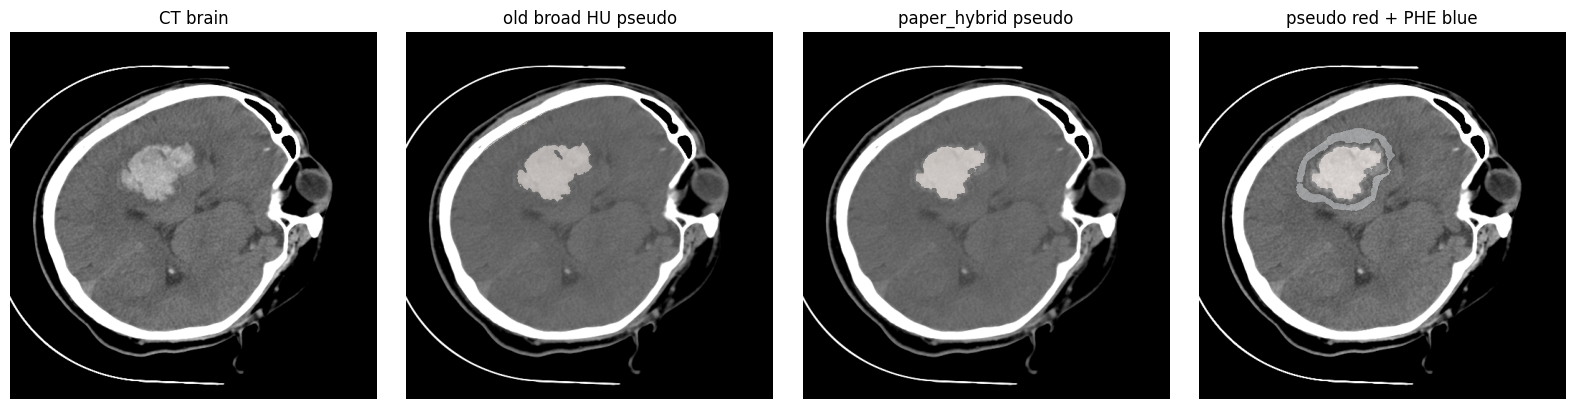

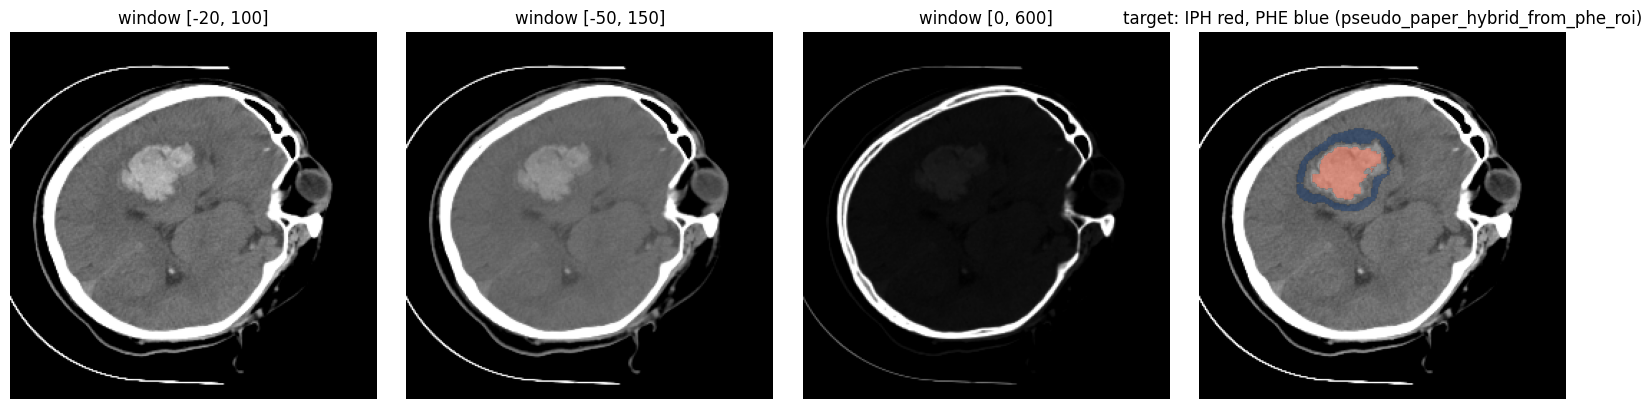

Sample scan: 0021 slice: 14 IPH source: pseudo_paper_hybrid_from_phe_roi


In [5]:
def window_ct(image: np.ndarray, low: float, high: float) -> np.ndarray:
    image = image.astype(np.float32, copy=False)
    image = np.clip(image, low, high)
    return ((image - low) / max(high - low, 1e-6)).astype(np.float32)


def resize_2d(array: np.ndarray, out_size: int, order: int = 1) -> np.ndarray:
    if array.shape[-2:] == (out_size, out_size):
        return array
    if not SCIPY_AVAILABLE:
        raise ImportError("Install scipy for resizing.")
    zoom_y = out_size / array.shape[-2]
    zoom_x = out_size / array.shape[-1]
    return ndimage.zoom(array, (zoom_y, zoom_x), order=order)


def make_25d_multiwindow_stack(volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    # Returns [D, C_window, H, W].
    n_slices = volume.shape[2]
    depth_items = []
    for off in CFG.slice_offsets:
        zi = int(np.clip(z + int(off), 0, n_slices - 1))
        channels = []
        for low, high in CFG.ct_windows:
            x = window_ct(np.asarray(volume[:, :, zi]), low, high)
            channels.append(resize_2d(x, image_size, order=1))
        depth_items.append(np.stack(channels, axis=0))
    return np.stack(depth_items, axis=0).astype(np.float32)


def preprocess_target_slice(target_volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    y = np.asarray(target_volume[:, :, z]).astype(np.uint8)
    return resize_2d(y, image_size, order=0).astype(np.int64)


def largest_label_slice(mask_volume: np.ndarray) -> int:
    fg = mask_volume > 0
    per_slice = fg.reshape((-1, fg.shape[2])).sum(axis=0)
    return int(np.argmax(per_slice))


def remove_small_components(mask: np.ndarray, spacing: Tuple[float, float, float], min_ml: float, max_components: Optional[int] = None) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(labeled.ravel()).astype(np.float64)
    sizes[0] = 0.0
    min_voxels = max(1, int(round((float(min_ml) * 1000.0) / max(np.prod(spacing), 1e-6))))
    candidates = np.where(sizes >= min_voxels)[0]
    candidates = candidates[candidates != 0]
    if len(candidates) == 0:
        return np.zeros_like(mask, dtype=bool)
    order = candidates[np.argsort(sizes[candidates])[::-1]]
    if max_components is not None:
        order = order[: int(max_components)]
    keep = np.zeros(n + 1, dtype=bool)
    keep[order] = True
    return keep[labeled]


def dilate_mm(mask: np.ndarray, spacing: Tuple[float, float, float], radius_mm: float) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    # Distance transform of the complement gives distance to the nearest positive voxel.
    dist = ndimage.distance_transform_edt(~mask, sampling=spacing)
    return dist <= float(radius_mm)


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float(mask.astype(bool).sum() * np.prod(spacing) / 1000.0)


def load_true_iph_if_available(row: pd.Series):
    if CFG.true_iph_mask_dir is None:
        return None
    mask_dir = Path(CFG.true_iph_mask_dir)
    candidates = [
        mask_dir / Path(row["phe_mask_path"]).name,
        mask_dir / f"{row['scan_id']}.nii.gz",
        mask_dir / f"{row['scan_id']}.nii",
    ]
    for path in candidates:
        if path.exists():
            mask, _, _ = load_nifti(path)
            return mask > 0
    return None


def generate_legacy_pseudo_iph(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
    """Original broad HU/PHE-dilation pseudo rule, kept only for visual comparison."""
    phe = phe_mask.astype(bool)
    roi = dilate_mm(phe, spacing, 18.0)
    hu_candidate = np.isfinite(volume) & (volume >= 40.0) & (volume <= 100.0)
    candidate = hu_candidate & roi & (~phe)
    return remove_small_components(candidate, spacing, min_ml=0.03, max_components=3).astype(bool)


def phe_bbox_roi(phe: np.ndarray, spacing: Tuple[float, float, float], margin_mm: float, z_margin: int) -> np.ndarray:
    """Constrain pseudo IPH to a case-local neighborhood around the manual PHE mask."""
    phe = phe.astype(bool)
    roi = np.zeros_like(phe, dtype=bool)
    if phe.sum() == 0:
        return roi
    coords = np.where(phe)
    margins = [int(np.ceil(float(margin_mm) / max(float(spacing[i]), 1e-6))) for i in range(3)]
    margins[2] = int(max(z_margin, margins[2] // 2))
    slices = []
    for axis, values in enumerate(coords):
        lo = max(0, int(values.min()) - margins[axis])
        hi = min(phe.shape[axis], int(values.max()) + margins[axis] + 1)
        slices.append(slice(lo, hi))
    roi[tuple(slices)] = True
    return roi


def component_physical_stats(mask: np.ndarray, component: np.ndarray, spacing: Tuple[float, float, float]) -> Dict:
    coords = np.where(component)
    if len(coords[0]) == 0:
        return {"long_axis_mm": 0.0, "extent": 0.0}
    axis_lengths = []
    bbox_voxels = 1
    for axis, values in enumerate(coords):
        length_vox = int(values.max() - values.min() + 1)
        bbox_voxels *= max(1, length_vox)
        axis_lengths.append(length_vox * float(spacing[axis]))
    return {
        "long_axis_mm": float(max(axis_lengths)),
        "extent": float(component.sum() / max(bbox_voxels, 1)),
    }


def otsu_threshold_np(values: np.ndarray, low: float, high: float, bins: int = 128) -> float:
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    values = values[(values >= low) & (values <= high)]
    if values.size < 16:
        return float((low + high) / 2.0)
    hist, edges = np.histogram(values, bins=int(bins), range=(float(low), float(high)))
    hist = hist.astype(np.float64)
    centers = (edges[:-1] + edges[1:]) / 2.0
    total = hist.sum()
    if total <= 0:
        return float((low + high) / 2.0)
    weight_bg = np.cumsum(hist)
    weight_fg = total - weight_bg
    mean_bg = np.cumsum(hist * centers) / np.maximum(weight_bg, 1e-6)
    mean_fg = (np.cumsum((hist * centers)[::-1]) / np.maximum(np.cumsum(hist[::-1]), 1e-6))[::-1]
    between = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
    return float(centers[int(np.nanargmax(between))])


def largest_component(mask: np.ndarray) -> np.ndarray:
    labeled, n = ndimage.label(mask.astype(bool))
    if n == 0:
        return np.zeros_like(mask, dtype=bool)
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    return labeled == int(np.argmax(sizes))


def estimate_brain_mask(volume: np.ndarray) -> np.ndarray:
    finite = np.isfinite(volume)
    brain = finite & (volume > -30.0) & (volume < 120.0)
    if brain.sum() == 0:
        return finite
    structure = ndimage.generate_binary_structure(3, 1)
    brain = ndimage.binary_closing(brain, structure=structure, iterations=1)
    brain = ndimage.binary_fill_holes(brain)
    return largest_component(brain)


def morph_filter_2d(mask: np.ndarray, close_px: int = 5, open_px: int = 3) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    close_px = max(1, int(close_px))
    open_px = max(1, int(open_px))
    close_struct = np.ones((close_px, close_px), dtype=bool)
    open_struct = np.ones((open_px, open_px), dtype=bool)
    out = np.zeros_like(mask, dtype=bool)
    for z in range(mask.shape[2]):
        sl = mask[:, :, z]
        if sl.sum() == 0:
            continue
        sl = ndimage.binary_closing(sl, structure=close_struct)
        # A small opening mimics the paper's erosion/dilation cleanup without deleting tiny IPH aggressively.
        sl = ndimage.binary_opening(sl, structure=open_struct)
        sl = ndimage.binary_fill_holes(sl)
        out[:, :, z] = sl
    return out


def generate_paper_hybrid_pseudo_iph_with_debug(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]):
    """Paper-guided pseudo IPH: fixed HU branch + local Otsu branch inside PHE-derived ROI."""
    phe = phe_mask.astype(bool)
    if phe.sum() == 0:
        empty = np.zeros_like(phe, dtype=bool)
        return empty, {"reason": "empty_phe"}

    finite = np.isfinite(volume)
    dist_to_phe = ndimage.distance_transform_edt(~phe, sampling=spacing)
    seed_roi = dist_to_phe <= float(CFG.pseudo_seed_roi_mm)
    grow_roi = dist_to_phe <= float(CFG.pseudo_grow_roi_mm)
    bbox_roi = phe_bbox_roi(phe, spacing, CFG.pseudo_bbox_margin_mm, CFG.pseudo_z_margin_slices)
    paper_roi = grow_roi & bbox_roi
    if CFG.pseudo_use_brain_mask:
        paper_roi = paper_roi & estimate_brain_mask(volume)

    hu_low = float(CFG.pseudo_otsu_hu_low)
    hu_high = float(CFG.pseudo_otsu_hu_high)
    fixed_branch = finite & paper_roi & (volume >= float(CFG.pseudo_fixed_hu_threshold)) & (volume <= hu_high)

    otsu_values = volume[finite & paper_roi & (volume >= hu_low) & (volume <= hu_high)]
    otsu_th = otsu_threshold_np(otsu_values, hu_low, hu_high, CFG.pseudo_otsu_bins)
    adaptive_branch = finite & paper_roi & (volume >= otsu_th) & (volume >= hu_low) & (volume <= hu_high)

    seed = (fixed_branch | (adaptive_branch & seed_roi)) & bbox_roi
    candidate = (fixed_branch | adaptive_branch) & paper_roi
    if CFG.pseudo_remove_phe_overlap:
        seed = seed & (~phe)
        candidate = candidate & (~phe)

    candidate = morph_filter_2d(candidate, CFG.pseudo_morph_close_px, CFG.pseudo_morph_open_px)
    candidate = candidate & paper_roi
    if CFG.pseudo_remove_phe_overlap:
        candidate = candidate & (~phe)
    if CFG.pseudo_fill_holes and candidate.sum() > 0:
        candidate = ndimage.binary_closing(candidate, structure=ndimage.generate_binary_structure(3, 1), iterations=1)
        candidate = ndimage.binary_fill_holes(candidate) & paper_roi
        if CFG.pseudo_remove_phe_overlap:
            candidate = candidate & (~phe)

    refined = select_refined_components(candidate, seed, volume, phe, dist_to_phe, spacing)
    debug = {
        "mode": "paper_hybrid",
        "otsu_threshold": float(otsu_th),
        "fixed_voxels": int(fixed_branch.sum()),
        "adaptive_voxels": int(adaptive_branch.sum()),
        "seed_voxels": int(seed.sum()),
        "candidate_voxels": int(candidate.sum()),
        "refined_voxels": int(refined.sum()),
        "candidate_ml": float(volume_ml(candidate, spacing)),
        "refined_ml": float(volume_ml(refined, spacing)),
    }
    return refined.astype(bool), debug


def select_refined_components(
    candidate: np.ndarray,
    seed: np.ndarray,
    volume: np.ndarray,
    phe: np.ndarray,
    dist_to_phe: np.ndarray,
    spacing: Tuple[float, float, float],
) -> np.ndarray:
    labeled, n = ndimage.label(candidate.astype(bool))
    if n == 0:
        return np.zeros_like(candidate, dtype=bool)

    voxel_ml = float(np.prod(spacing) / 1000.0)
    keep_rows = []
    contact_shell = dist_to_phe <= float(CFG.pseudo_contact_mm)

    for label_id in range(1, n + 1):
        comp = labeled == label_id
        voxels = int(comp.sum())
        ml = float(voxels * voxel_ml)
        if ml < float(CFG.pseudo_min_component_ml):
            continue
        if ml > float(CFG.pseudo_max_component_ml):
            continue

        seed_voxels = int(np.logical_and(comp, seed).sum())
        if seed_voxels < int(CFG.pseudo_min_seed_voxels):
            continue

        hu_values = volume[comp]
        mean_hu = float(np.nanmean(hu_values)) if hu_values.size else 0.0
        if mean_hu < float(CFG.pseudo_min_mean_hu):
            continue

        phys = component_physical_stats(candidate, comp, spacing)
        if phys["long_axis_mm"] > float(CFG.pseudo_max_long_axis_mm):
            continue
        if ml > 0.5 and phys["extent"] < float(CFG.pseudo_min_extent_large_component):
            continue

        contact_ratio = float(np.logical_and(comp, contact_shell).sum() / max(voxels, 1))
        min_dist = float(np.min(dist_to_phe[comp])) if voxels else np.inf
        phe_touch = int(np.logical_and(dilate_mm(comp, spacing, CFG.pseudo_contact_mm), phe).sum())

        # Prefer compact high-HU components that seed strongly and touch/approach PHE.
        score = (
            4.0 * np.log1p(seed_voxels)
            + 2.0 * np.log1p(voxels)
            + 3.0 * contact_ratio
            + 0.05 * mean_hu
            - 0.35 * min_dist
            + (1.5 if phe_touch > 0 else 0.0)
        )
        keep_rows.append((score, label_id, ml, mean_hu, seed_voxels, contact_ratio, min_dist))

    if not keep_rows:
        return np.zeros_like(candidate, dtype=bool)

    keep_rows = sorted(keep_rows, reverse=True)[: int(CFG.pseudo_max_components)]
    keep_ids = {label_id for _, label_id, *_ in keep_rows}
    return np.isin(labeled, list(keep_ids))


def generate_seed_grow_pseudo_iph_with_debug(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]):
    """02-4/02-8 seed-grow pseudo hemorrhage, kept as fallback."""
    phe = phe_mask.astype(bool)
    if phe.sum() == 0:
        empty = np.zeros_like(phe, dtype=bool)
        return empty, {"reason": "empty_phe"}

    finite = np.isfinite(volume)
    dist_to_phe = ndimage.distance_transform_edt(~phe, sampling=spacing)
    seed_roi = dist_to_phe <= float(CFG.pseudo_seed_roi_mm)
    grow_roi = dist_to_phe <= float(CFG.pseudo_grow_roi_mm)
    bbox_roi = phe_bbox_roi(phe, spacing, CFG.pseudo_bbox_margin_mm, CFG.pseudo_z_margin_slices)

    seed_hu = finite & (volume >= CFG.pseudo_seed_hu_low) & (volume <= CFG.pseudo_seed_hu_high)
    grow_hu = finite & (volume >= CFG.pseudo_grow_hu_low) & (volume <= CFG.pseudo_grow_hu_high)

    seed = seed_hu & seed_roi & bbox_roi
    grow_mask = grow_hu & grow_roi & bbox_roi
    if CFG.pseudo_remove_phe_overlap:
        seed = seed & (~phe)
        grow_mask = grow_mask & (~phe)

    if seed.sum() > 0:
        candidate = ndimage.binary_propagation(seed, mask=grow_mask)
    else:
        candidate = np.zeros_like(grow_mask, dtype=bool)

    if CFG.pseudo_fill_holes and candidate.sum() > 0:
        candidate = ndimage.binary_closing(
            candidate,
            structure=ndimage.generate_binary_structure(3, 1),
            iterations=1,
        )
        candidate = candidate & grow_mask
        candidate = ndimage.binary_fill_holes(candidate) & grow_mask

    refined = select_refined_components(candidate, seed, volume, phe, dist_to_phe, spacing)
    debug = {
        "mode": "seed_grow",
        "seed_voxels": int(seed.sum()),
        "grow_voxels": int(grow_mask.sum()),
        "candidate_voxels": int(candidate.sum()),
        "refined_voxels": int(refined.sum()),
        "candidate_ml": float(volume_ml(candidate, spacing)),
        "refined_ml": float(volume_ml(refined, spacing)),
    }
    return refined.astype(bool), debug


def generate_pseudo_iph_with_debug(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]):
    if str(CFG.pseudo_generation_mode).lower() == "paper_hybrid":
        return generate_paper_hybrid_pseudo_iph_with_debug(volume, phe_mask, spacing)
    return generate_seed_grow_pseudo_iph_with_debug(volume, phe_mask, spacing)


def generate_pseudo_iph(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
    pseudo, _ = generate_pseudo_iph_with_debug(volume, phe_mask, spacing)
    return pseudo.astype(bool)


def build_multiclass_target(row: pd.Series, image: Optional[np.ndarray] = None, phe_mask: Optional[np.ndarray] = None, spacing: Optional[Tuple[float, float, float]] = None):
    if image is None:
        image, spacing, _ = load_nifti(Path(row["img_path"]))
    if phe_mask is None:
        phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
    if spacing is None:
        _, spacing, _ = load_nifti(Path(row["img_path"]))

    phe = phe_mask > 0
    iph = load_true_iph_if_available(row)
    label_source_iph = "manual_or_external"
    if iph is None:
        iph = generate_pseudo_iph(image, phe, spacing)
        label_source_iph = f"pseudo_{CFG.pseudo_generation_mode}_from_phe_roi"

    target = np.zeros(phe.shape, dtype=np.uint8)
    target[iph.astype(bool)] = 1
    target[phe.astype(bool)] = 2
    return target, label_source_iph


# Visual sanity check for refined pseudo IPH and manual PHE.
sample_row = train_rows.sort_values("phe_volume_ml", ascending=False).iloc[0]
image, spacing, _ = load_nifti(Path(sample_row["img_path"]))
phe_mask, _, _ = load_nifti(Path(sample_row["phe_mask_path"]))
legacy_pseudo = generate_legacy_pseudo_iph(image, phe_mask > 0, spacing)
refined_pseudo, refined_debug = generate_pseudo_iph_with_debug(image, phe_mask > 0, spacing)
target, iph_source = build_multiclass_target(sample_row, image=image, phe_mask=phe_mask, spacing=spacing)
z = largest_label_slice((phe_mask > 0) | legacy_pseudo | refined_pseudo)
print("Pseudo comparison sample:", sample_row["scan_id"], refined_debug)
print("Legacy pseudo ml:", volume_ml(legacy_pseudo, spacing), "Refined pseudo ml:", volume_ml(refined_pseudo, spacing))

fig_cmp, axes_cmp = plt.subplots(1, 4, figsize=(16, 4))
brain = window_ct(np.asarray(image[:, :, z]), -20, 100)
blood = window_ct(np.asarray(image[:, :, z]), -50, 150)
for ax in axes_cmp:
    ax.axis("off")
axes_cmp[0].imshow(brain, cmap="gray")
axes_cmp[0].set_title("CT brain")
axes_cmp[1].imshow(blood, cmap="gray")
axes_cmp[1].imshow(np.ma.masked_where(~legacy_pseudo[:, :, z], legacy_pseudo[:, :, z]), cmap="Reds", alpha=0.45)
axes_cmp[1].set_title("old broad HU pseudo")
axes_cmp[2].imshow(blood, cmap="gray")
axes_cmp[2].imshow(np.ma.masked_where(~refined_pseudo[:, :, z], refined_pseudo[:, :, z]), cmap="Reds", alpha=0.55)
axes_cmp[2].set_title(f"{CFG.pseudo_generation_mode} pseudo")
axes_cmp[3].imshow(brain, cmap="gray")
axes_cmp[3].imshow(np.ma.masked_where((phe_mask[:, :, z] <= 0), phe_mask[:, :, z]), cmap="Blues", alpha=0.40)
axes_cmp[3].imshow(np.ma.masked_where(~refined_pseudo[:, :, z], refined_pseudo[:, :, z]), cmap="Reds", alpha=0.50)
axes_cmp[3].set_title("pseudo red + PHE blue")
plt.tight_layout()
plt.savefig(FIG_DIR / "3dff_refined_vs_legacy_pseudo_sample.png", dpi=160, bbox_inches="tight")
plt.show()

x_small = make_25d_multiwindow_stack(image, z, image_size=256)
y_small = preprocess_target_slice(target, z, image_size=256)

fig, axes = plt.subplots(1, len(CFG.ct_windows) + 1, figsize=(4 * (len(CFG.ct_windows) + 1), 4))
mid = len(CFG.slice_offsets) // 2
for c, (low, high) in enumerate(CFG.ct_windows):
    axes[c].imshow(x_small[mid, c], cmap="gray")
    axes[c].set_title(f"window [{low:g}, {high:g}]")
    axes[c].axis("off")
axes[-1].imshow(x_small[mid, 0], cmap="gray")
axes[-1].imshow(np.ma.masked_where(y_small != 1, y_small), cmap="Reds", alpha=0.50, vmin=0, vmax=2)
axes[-1].imshow(np.ma.masked_where(y_small != 2, y_small), cmap="Blues", alpha=0.45, vmin=0, vmax=2)
axes[-1].set_title(f"target: IPH red, PHE blue ({iph_source})")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "3dff_sample_multiclass_target_refined_pseudo.png", dpi=160, bbox_inches="tight")
plt.show()
print("Sample scan:", sample_row["scan_id"], "slice:", z, "IPH source:", iph_source)


### Paper-guided pseudo-label policy

The training target still has classes `background/IPH/PHE`. PHE is the manual mask. IPH is pseudo-label unless `CFG.true_iph_mask_dir` is set.

`02-9` uses a paper-guided hybrid pseudo IPH rule: fixed high-HU branch plus local Otsu branch inside a PHE-derived ROI, with HU constrained to plausible acute blood range and morphology cleanup.


## 5. Benchmark-compatible metrics


In [6]:
def diagonal_distance(shape: Sequence[int], sampling: Optional[Sequence[float]] = None) -> float:
    if sampling is None:
        sampling = [1.0] * len(shape)
    return float(math.sqrt(sum(((int(s) - 1) * float(sp)) ** 2 for s, sp in zip(shape, sampling))))


def confusion_counts(pred: np.ndarray, target: np.ndarray):
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp = int(np.logical_and(pred, target).sum())
    fp = int(np.logical_and(pred, ~target).sum())
    fn = int(np.logical_and(~pred, target).sum())
    tn = int(np.logical_and(~pred, ~target).sum())
    return tp, fp, fn, tn


def overlap_metrics(pred: np.ndarray, target: np.ndarray) -> Dict:
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp, fp, fn, tn = confusion_counts(pred, target)
    pred_pos = tp + fp
    target_pos = tp + fn
    union = tp + fp + fn
    if target_pos == 0 and pred_pos == 0:
        dice = np.nan
        jaccard = np.nan
        precision = np.nan
        recall = np.nan
    else:
        dice = float((2 * tp) / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan
        jaccard = float(tp / union) if union else np.nan
        precision = float(tp / pred_pos) if pred_pos else 0.0
        recall = float(tp / target_pos) if target_pos else np.nan
    specificity = float(tn / (tn + fp)) if (tn + fp) else np.nan
    return {
        "dice": dice,
        "jaccard": jaccard,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def surface_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    structure = ndimage.generate_binary_structure(mask.ndim, 1)
    eroded = ndimage.binary_erosion(mask, structure=structure, border_value=0)
    return np.logical_xor(mask, eroded)


def surface_distances(pred: np.ndarray, target: np.ndarray, sampling: Sequence[float]):
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 or target.sum() == 0:
        return None, None
    sp = surface_mask(pred)
    st = surface_mask(target)
    if sp.sum() == 0 or st.sum() == 0:
        return None, None
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=sampling)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=sampling)
    return dt_to_target[sp], dt_to_pred[st]


def distance_metrics(pred: np.ndarray, target: np.ndarray, sampling: Sequence[float], empty_penalty: bool = True) -> Dict:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return {"hd_mm": np.nan, "hd95_mm": np.nan, "assd_mm": np.nan}
    if pred.sum() == 0 or target.sum() == 0:
        penalty = diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
        return {"hd_mm": penalty, "hd95_mm": penalty, "assd_mm": penalty}
    d_pred_to_target, d_target_to_pred = surface_distances(pred, target, sampling)
    if d_pred_to_target is None or d_target_to_pred is None:
        penalty = diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
        return {"hd_mm": penalty, "hd95_mm": penalty, "assd_mm": penalty}
    all_d = np.concatenate([d_pred_to_target, d_target_to_pred]).astype(float)
    return {
        "hd_mm": float(np.max(all_d)),
        "hd95_mm": float(np.percentile(all_d, 95)),
        "assd_mm": float(np.mean(all_d)),
    }


def normalized_surface_dice(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], tolerance_mm: float = CFG.nsd_tolerance_mm) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return 0.0
    d_pred_to_target, d_target_to_pred = surface_distances(pred, target, spacing)
    if d_pred_to_target is None or d_target_to_pred is None:
        return 0.0
    close_pred = int((d_pred_to_target <= tolerance_mm).sum())
    close_target = int((d_target_to_pred <= tolerance_mm).sum())
    denom = int(len(d_pred_to_target) + len(d_target_to_pred))
    return float((close_pred + close_target) / denom) if denom else np.nan


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float(mask.astype(bool).sum() * np.prod(spacing) / 1000.0)


def rvd_signed(pred: np.ndarray, target: np.ndarray) -> float:
    pred_vox = float(pred.astype(bool).sum())
    target_vox = float(target.astype(bool).sum())
    if target_vox == 0:
        return np.nan if pred_vox == 0 else np.inf
    return float((pred_vox - target_vox) / target_vox)


def rvd_abs(pred: np.ndarray, target: np.ndarray) -> float:
    value = rvd_signed(pred, target)
    return float(abs(value)) if np.isfinite(value) else value


def r2_score_np(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def evaluate_volume_multiclass(scan_id: str, pred_label: np.ndarray, target_label: np.ndarray, spacing: Tuple[float, float, float], label_source_iph: str = "unknown") -> pd.DataFrame:
    rows = []
    for class_id in CLASS_IDS:
        pred = pred_label == class_id
        target = target_label == class_id
        overlap = overlap_metrics(pred, target)
        dist = distance_metrics(pred, target, sampling=spacing, empty_penalty=True)
        pred_ml = volume_ml(pred, spacing)
        target_ml = volume_ml(target, spacing)
        rows.append({
            "scan_id": scan_id,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "label_source": label_source_iph if class_id == 1 else "manual",
            "gt_positive": bool(target.sum() > 0),
            "pred_positive": bool(pred.sum() > 0),
            "detected": bool(pred.sum() > 0) if target.sum() > 0 else np.nan,
            "false_positive_case": bool(pred.sum() > 0) if target.sum() == 0 else np.nan,
            "dsc": overlap["dice"],
            "jaccard": overlap["jaccard"],
            "precision": overlap["precision"],
            "recall": overlap["recall"],
            "specificity": overlap["specificity"],
            "hd_mm": dist["hd_mm"],
            "hd95_mm": dist["hd95_mm"],
            "assd_mm": dist["assd_mm"],
            "nsd_1mm": normalized_surface_dice(pred, target, spacing, tolerance_mm=CFG.nsd_tolerance_mm),
            "pred_volume_ml": pred_ml,
            "target_volume_ml": target_ml,
            "volume_abs_error_ml": abs(pred_ml - target_ml),
            "volume_sq_error_ml2": (pred_ml - target_ml) ** 2,
            "rvd": rvd_abs(pred, target),
            "rvd_signed": rvd_signed(pred, target),
            **{k: overlap[k] for k in ["tp", "fp", "fn", "tn"]},
        })
    return pd.DataFrame(rows)


def evaluate_slice_multiclass(scan_id: str, pred_label: np.ndarray, target_label: np.ndarray, spacing: Tuple[float, float, float], positive_gt_only: bool = False) -> pd.DataFrame:
    rows = []
    for z in range(target_label.shape[2]):
        for class_id in CLASS_IDS:
            pred = pred_label[:, :, z] == class_id
            target = target_label[:, :, z] == class_id
            if positive_gt_only and target.sum() == 0:
                continue
            overlap = overlap_metrics(pred, target)
            dist = distance_metrics(pred, target, sampling=spacing[:2], empty_penalty=True)
            rows.append({
                "scan_id": scan_id,
                "slice_idx": z,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "gt_positive": bool(target.sum() > 0),
                "pred_positive": bool(pred.sum() > 0),
                "dice": overlap["dice"],
                "jaccard": overlap["jaccard"],
                "precision": overlap["precision"],
                "recall": overlap["recall"],
                "hd_mm": dist["hd_mm"],
                "hd95_mm": dist["hd95_mm"],
            })
    return pd.DataFrame(rows)


def summarize_metrics(df: pd.DataFrame, group_name: str, cols: Optional[List[str]] = None, group_cols: Sequence[str] = ("class_name",)) -> pd.DataFrame:
    cols = cols or ["dsc", "jaccard", "precision", "recall", "hd95_mm", "assd_mm", "nsd_1mm", "rvd", "volume_abs_error_ml"]
    rows = []
    grouped = df.groupby(list(group_cols), dropna=False) if group_cols else [((), df)]
    for keys, part in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)
        base = {"group": group_name}
        for name, value in zip(group_cols, keys):
            base[name] = value
        for col in cols:
            if col not in part.columns:
                continue
            values = pd.to_numeric(part[col], errors="coerce")
            finite = values.replace([np.inf, -np.inf], np.nan)
            rows.append({
                **base,
                "metric": col,
                "mean": finite.mean(),
                "std": finite.std(),
                "median": finite.median(),
                "n": int(finite.notna().sum()),
                "n_inf": int(np.isinf(values).sum()),
            })
    return pd.DataFrame(rows)


## 6. Metric sanity checks


In [7]:
# These checks catch common mistakes before paper-style reporting.
a = np.zeros((16, 16, 8), dtype=np.uint8)
b = np.zeros_like(a)
a[4:10, 4:10, 2:5] = 1
b[4:10, 4:10, 2:5] = 1
same = evaluate_volume_multiclass("unit_same", a, b, spacing=(1.0, 1.0, 2.0))
assert np.isclose(same.loc[same.class_id == 1, "dsc"].iloc[0], 1.0)
assert np.isclose(same.loc[same.class_id == 1, "hd95_mm"].iloc[0], 0.0)

c = np.zeros_like(a)
c[5:11, 4:10, 2:5] = 1
shifted = evaluate_volume_multiclass("unit_shifted", c, b, spacing=(1.0, 1.0, 2.0))
assert shifted.loc[shifted.class_id == 1, "dsc"].iloc[0] < 1.0
assert shifted.loc[shifted.class_id == 1, "hd95_mm"].iloc[0] > 0.0

empty = np.zeros_like(a)
empty_case = evaluate_volume_multiclass("unit_empty", empty, empty, spacing=(1.0, 1.0, 2.0))
assert np.isnan(empty_case.loc[empty_case.class_id == 1, "dsc"].iloc[0])

missed = evaluate_volume_multiclass("unit_missed", empty, b, spacing=(1.0, 1.0, 2.0))
assert np.isclose(missed.loc[missed.class_id == 1, "dsc"].iloc[0], 0.0)
assert missed.loc[missed.class_id == 1, "hd95_mm"].iloc[0] > 0.0

print("Metric sanity checks passed.")


Metric sanity checks passed.


## 7. Dataset


In [8]:
if TORCH_AVAILABLE:
    class BrainLesion25DDataset(Dataset):
        def __init__(self, df: pd.DataFrame, image_size: int = CFG.image_size, augment: bool = False):
            self.df = df.copy().reset_index(drop=True)
            self.image_size = int(image_size)
            self.augment = bool(augment)
            self.cache = {}
            self.slice_df = self._build_slice_index()

        def _load_case(self, row_idx: int):
            if row_idx not in self.cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
                target, iph_source = build_multiclass_target(row, image=image, phe_mask=phe_mask, spacing=spacing)
                self.cache[row_idx] = (image.astype(np.float32), target.astype(np.uint8), spacing, iph_source)
            return self.cache[row_idx]

        def _build_slice_index(self):
            rows = []
            for row_idx, row in tqdm(list(self.df.iterrows()), desc="index slices", leave=False):
                image, target, spacing, iph_source = self._load_case(int(row_idx))
                n = target.shape[2]
                for z in range(n):
                    iph_pixels = int((target[:, :, z] == 1).sum())
                    phe_pixels = int((target[:, :, z] == 2).sum())
                    rows.append({
                        "row_idx": int(row_idx),
                        "scan_id": row["scan_id"],
                        "slice_idx": int(z),
                        "positive": bool((iph_pixels + phe_pixels) > 0),
                        "positive_iph": bool(iph_pixels > 0),
                        "positive_phe": bool(phe_pixels > 0),
                        "iph_pixels": iph_pixels,
                        "phe_pixels": phe_pixels,
                        "iph_source": iph_source,
                    })
            return pd.DataFrame(rows)

        def _elastic_deform_2d(self, x: np.ndarray, y: np.ndarray):
            """Elastic deformation for 2D slices. x: [D, C, H, W], y: [H, W]."""
            h, w = x.shape[-2], x.shape[-1]
            dx = ndimage.gaussian_filter(np.random.randn(h, w).astype(np.float32), CFG.elastic_sigma) * CFG.elastic_alpha
            dy = ndimage.gaussian_filter(np.random.randn(h, w).astype(np.float32), CFG.elastic_sigma) * CFG.elastic_alpha
            y_grid, x_grid = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
            coords_y = np.clip(y_grid + dy, 0, h - 1).astype(np.float64)
            coords_x = np.clip(x_grid + dx, 0, w - 1).astype(np.float64)
            flat = x.reshape((-1, h, w))
            deformed = np.stack([
                ndimage.map_coordinates(ch, [coords_y, coords_x], order=1, mode="nearest")
                for ch in flat
            ], axis=0).reshape(x.shape)
            deformed_y = ndimage.map_coordinates(
                y.astype(np.float64), [coords_y, coords_x], order=0, mode="nearest"
            ).astype(y.dtype)
            return deformed.astype(np.float32), deformed_y

        def _augment(self, x: np.ndarray, y: np.ndarray):
            # x: [D, C, H, W], y: [H, W]
            h, w = x.shape[-2], x.shape[-1]

            # Horizontal flip
            if random.random() < 0.5:
                x = np.flip(x, axis=3).copy()
                y = np.flip(y, axis=1).copy()

            # Random rotation (stronger)
            if random.random() < CFG.aug_rotate_prob:
                angle = random.uniform(-CFG.aug_rotate_range, CFG.aug_rotate_range)
                flat = x.reshape((-1, h, w))
                flat = np.stack([ndimage.rotate(ch, angle, reshape=False, order=1, mode="nearest") for ch in flat], axis=0)
                x = flat.reshape(x.shape)
                y = ndimage.rotate(y, angle, reshape=False, order=0, mode="nearest")

            # Random scale
            if random.random() < CFG.aug_scale_prob:
                scale = random.uniform(*CFG.aug_scale_range)
                new_h, new_w = int(round(h * scale)), int(round(w * scale))
                if new_h > 0 and new_w > 0:
                    flat = x.reshape((-1, h, w))
                    flat_s = np.stack([ndimage.zoom(ch, (new_h / h, new_w / w), order=1) for ch in flat], axis=0)
                    y_s = ndimage.zoom(y.astype(np.float64), (new_h / h, new_w / w), order=0).astype(y.dtype)
                    if scale > 1.0:
                        sh = (new_h - h) // 2
                        sw = (new_w - w) // 2
                        flat = flat_s[:, sh:sh + h, sw:sw + w]
                        y = y_s[sh:sh + h, sw:sw + w]
                    else:
                        ph = (h - new_h) // 2
                        pw = (w - new_w) // 2
                        flat = np.zeros_like(x.reshape((-1, h, w)))
                        flat[:, ph:ph + new_h, pw:pw + new_w] = flat_s
                        y_new = np.zeros((h, w), dtype=y.dtype)
                        y_new[ph:ph + new_h, pw:pw + new_w] = y_s
                        y = y_new
                    x = flat.reshape(x.shape)

            # Elastic deformation
            if CFG.use_elastic_deform and random.random() < 0.15:
                x, y = self._elastic_deform_2d(x, y)

            # Gamma correction (stronger range)
            if random.random() < CFG.aug_gamma_prob:
                gamma = random.uniform(*CFG.aug_gamma_range)
                x = np.clip(x, 0, 1) ** gamma

            # Gaussian noise
            if random.random() < 0.12:
                x = np.clip(x + np.random.normal(0, 0.010, size=x.shape).astype(np.float32), 0, 1)

            # Gaussian blur
            if random.random() < CFG.aug_blur_prob:
                sigma = random.uniform(*CFG.aug_blur_sigma)
                flat = x.reshape((-1, h, w))
                flat = np.stack([ndimage.gaussian_filter(ch, sigma=sigma) for ch in flat], axis=0)
                x = flat.reshape(x.shape)

            # Brightness shift
            if random.random() < CFG.aug_brightness_prob:
                shift = random.uniform(-CFG.aug_brightness_range, CFG.aug_brightness_range)
                x = np.clip(x + shift, 0, 1)

            # Target-aware cutout: regularize context without frequently erasing the lesion.
            if random.random() < CFG.aug_cutout_prob:
                lesion = y > 0
                for _ in range(CFG.aug_cutout_holes):
                    placed = False
                    for _attempt in range(10):
                        ch_start = random.randint(0, max(0, h - CFG.aug_cutout_size))
                        cw_start = random.randint(0, max(0, w - CFG.aug_cutout_size))
                        patch = lesion[
                            ch_start:ch_start + CFG.aug_cutout_size,
                            cw_start:cw_start + CFG.aug_cutout_size,
                        ]
                        # Prefer non-lesion context; allow rare lesion overlap to keep augmentation useful.
                        if patch.sum() == 0 or random.random() < 0.10:
                            x[
                                ...,
                                ch_start:ch_start + CFG.aug_cutout_size,
                                cw_start:cw_start + CFG.aug_cutout_size,
                            ] = 0.0
                            placed = True
                            break
                    if not placed and not lesion.any():
                        ch_start = random.randint(0, max(0, h - CFG.aug_cutout_size))
                        cw_start = random.randint(0, max(0, w - CFG.aug_cutout_size))
                        x[
                            ...,
                            ch_start:ch_start + CFG.aug_cutout_size,
                            cw_start:cw_start + CFG.aug_cutout_size,
                        ] = 0.0

            return x.astype(np.float32), y.astype(np.int64)

        def __len__(self):
            return len(self.slice_df)

        def __getitem__(self, idx):
            item = self.slice_df.iloc[idx]
            image, target, spacing, iph_source = self._load_case(int(item["row_idx"]))
            z = int(item["slice_idx"])
            x = make_25d_multiwindow_stack(image, z, self.image_size)
            y = preprocess_target_slice(target, z, self.image_size)
            if self.augment:
                x, y = self._augment(x, y)
            return {
                "image": torch.from_numpy(x).float(),
                "target": torch.from_numpy(y).long(),
                "scan_id": str(item["scan_id"]),
                "slice_idx": int(z),
                "spacing": torch.tensor(spacing, dtype=torch.float32),
                "positive": bool(item["positive"]),
            }

    class PHEOnly25DDataset(Dataset):
        """Binary PHE wrapper over BrainLesion25DDataset; reuses the base cache."""
        def __init__(self, base_ds: BrainLesion25DDataset):
            self.base_ds = base_ds
            self.df = base_ds.df
            self.slice_df = base_ds.slice_df

        def __len__(self):
            return len(self.base_ds)

        def __getitem__(self, idx):
            sample = dict(self.base_ds[idx])
            sample["target"] = (sample["target"] == 2).long()
            return sample
else:
    print("Torch unavailable. Dataset skipped.")


## 8. Model: PESE-guided 3DFF-Net


In [9]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def load_resnet34_backbone():
        weights = None
        if CFG.pretrained_backbone:
            try:
                weights = ResNet34_Weights.DEFAULT
            except Exception:
                weights = None
        try:
            model = resnet34(weights=weights)
            print("ResNet34 weights:", "ImageNet" if weights is not None else "random")
        except Exception as exc:
            print("Could not load pretrained ResNet34; falling back to random:", exc)
            model = resnet34(weights=None)
        return model


    class SliceResNet34Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            base = load_resnet34_backbone()
            self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
            self.layer1 = base.layer1
            self.layer2 = base.layer2
            self.layer3 = base.layer3
            self.layer4 = base.layer4

        def forward(self, x):
            x = self.stem(x)
            c2 = self.layer1(x)
            c3 = self.layer2(c2)
            c4 = self.layer3(c3)
            c5 = self.layer4(c4)
            return {"c2": c2, "c3": c3, "c4": c4, "c5": c5}


    def gn(channels: int):
        groups = 8
        while channels % groups != 0 and groups > 1:
            groups //= 2
        return nn.GroupNorm(groups, channels)


    class PESEGuided3DFeatureFusion(nn.Module):
        """Fuse 2.5D features with learned attention guided by a PESE-style slice prior."""
        def __init__(self, channels: int, depth: int):
            super().__init__()
            self.center = depth // 2
            hidden = max(8, channels // 16)
            self.local_depth = nn.Sequential(
                nn.Conv3d(channels, channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=channels, bias=False),
                nn.GroupNorm(gn(channels).num_groups, channels),
                nn.SiLU(inplace=True),
            )
            self.depth_collapse = nn.Conv3d(channels, channels, kernel_size=(depth, 1, 1), groups=channels, bias=False)
            self.attn_reduce = nn.Conv3d(channels, hidden, kernel_size=1)
            self.attn_score = nn.Conv3d(hidden, 1, kernel_size=1)
            self.center_scale = nn.Parameter(torch.tensor(0.35))
            self.pointwise = nn.Sequential(
                nn.Conv2d(channels, channels, kernel_size=1, bias=False),
                gn(channels),
                nn.SiLU(inplace=True),
            )

        def forward(self, x, prior_weights=None):
            x3 = x.permute(0, 2, 1, 3, 4).contiguous()
            local = self.local_depth(x3)
            collapsed = self.depth_collapse(local).squeeze(2)
            pooled = x3.mean(dim=(-1, -2), keepdim=True)
            scores = self.attn_score(F.silu(self.attn_reduce(pooled)))
            learned_weights = torch.softmax(scores, dim=2)
            if prior_weights is not None:
                prior = prior_weights[:, None, :, None, None].to(dtype=learned_weights.dtype, device=learned_weights.device)
                prior = prior / prior.sum(dim=2, keepdim=True).clamp_min(1e-6)
                strength = float(CFG.pese_prior_strength)
                weights = (1.0 - strength) * learned_weights + strength * prior
            else:
                weights = learned_weights
            attended = (x3 * weights).sum(dim=2)
            center = x3[:, :, self.center]
            return self.pointwise(collapsed + attended + self.center_scale * center)


    class FPN(nn.Module):
        def __init__(self, in_channels=(64, 128, 256, 512), out_channels=CFG.fpn_channels):
            super().__init__()
            self.laterals = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels])
            self.smooth = nn.ModuleList([
                nn.Sequential(nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False), gn(out_channels), nn.SiLU(inplace=True))
                for _ in in_channels
            ])

        def forward(self, feats: Dict[str, torch.Tensor]):
            c2, c3, c4, c5 = feats["c2"], feats["c3"], feats["c4"], feats["c5"]
            lat = [l(f) for l, f in zip(self.laterals, [c2, c3, c4, c5])]
            p5 = lat[3]
            p4 = lat[2] + F.interpolate(p5, size=lat[2].shape[-2:], mode="nearest")
            p3 = lat[1] + F.interpolate(p4, size=lat[1].shape[-2:], mode="nearest")
            p2 = lat[0] + F.interpolate(p3, size=lat[0].shape[-2:], mode="nearest")
            return {
                "p2": self.smooth[0](p2),
                "p3": self.smooth[1](p3),
                "p4": self.smooth[2](p4),
                "p5": self.smooth[3](p5),
            }


    class ConvGNAct(nn.Module):
        def __init__(self, in_ch, out_ch, dropout=0.0):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                gn(out_ch),
                nn.SiLU(inplace=True),
                nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                gn(out_ch),
                nn.SiLU(inplace=True),
            )

        def forward(self, x):
            return self.net(x)


    class SegmentationDecoder(nn.Module):
        def __init__(self, fpn_channels=CFG.fpn_channels, decoder_channels=CFG.decoder_channels, out_classes=CFG.num_classes):
            super().__init__()
            d0, d1, d2, d3 = decoder_channels
            self.fuse = ConvGNAct(fpn_channels * 4, d0, dropout=0.08)
            self.up1 = ConvGNAct(d0, d1, dropout=0.05)
            self.up2 = ConvGNAct(d1, d2, dropout=0.03)
            self.up3 = ConvGNAct(d2, d3, dropout=0.02)
            self.head = nn.Conv2d(d3, out_classes, 1)

            # Deep supervision auxiliary heads
            self._use_ds = bool(CFG.use_deep_supervision)
            if self._use_ds:
                self.aux_head_p3 = nn.Sequential(
                    nn.Conv2d(fpn_channels, fpn_channels // 2, 3, padding=1, bias=False),
                    gn(fpn_channels // 2), nn.SiLU(inplace=True),
                    nn.Conv2d(fpn_channels // 2, out_classes, 1),
                )
                self.aux_head_p4 = nn.Sequential(
                    nn.Conv2d(fpn_channels, fpn_channels // 2, 3, padding=1, bias=False),
                    gn(fpn_channels // 2), nn.SiLU(inplace=True),
                    nn.Conv2d(fpn_channels // 2, out_classes, 1),
                )
                self.aux_head_p5 = nn.Sequential(
                    nn.Conv2d(fpn_channels, fpn_channels // 4, 3, padding=1, bias=False),
                    gn(fpn_channels // 4), nn.SiLU(inplace=True),
                    nn.Conv2d(fpn_channels // 4, out_classes, 1),
                )

        def forward(self, pyramid: Dict[str, torch.Tensor]):
            p2 = pyramid["p2"]
            target_size = p2.shape[-2:]
            p3 = F.interpolate(pyramid["p3"], size=target_size, mode="bilinear", align_corners=False)
            p4 = F.interpolate(pyramid["p4"], size=target_size, mode="bilinear", align_corners=False)
            p5 = F.interpolate(pyramid["p5"], size=target_size, mode="bilinear", align_corners=False)
            x = self.fuse(torch.cat([p2, p3, p4, p5], dim=1))
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = self.up1(x)
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = self.up2(x)
            x = self.up3(x)
            main_logits = self.head(x)

            if self._use_ds and self.training:
                h, w = main_logits.shape[-2:]
                aux_p3 = F.interpolate(self.aux_head_p3(pyramid["p3"]), size=(h, w), mode="bilinear", align_corners=False)
                aux_p4 = F.interpolate(self.aux_head_p4(pyramid["p4"]), size=(h, w), mode="bilinear", align_corners=False)
                aux_p5 = F.interpolate(self.aux_head_p5(pyramid["p5"]), size=(h, w), mode="bilinear", align_corners=False)
                return main_logits, [aux_p3, aux_p4, aux_p5]

            return main_logits


    class ThreeDFFNet(nn.Module):
        def __init__(self, out_classes: int = CFG.num_classes):
            super().__init__()
            self.encoder = SliceResNet34Encoder()
            depth = len(CFG.slice_offsets)
            self.fusions = nn.ModuleDict({
                "c2": PESEGuided3DFeatureFusion(64, depth),
                "c3": PESEGuided3DFeatureFusion(128, depth),
                "c4": PESEGuided3DFeatureFusion(256, depth),
                "c5": PESEGuided3DFeatureFusion(512, depth),
            })
            self.center_depth = depth // 2
            self.fpn = FPN()
            self.decoder = SegmentationDecoder(out_classes=out_classes)

        def compute_pese_prior_weights(self, x):
            if not bool(CFG.use_pese_guided_fusion):
                return None
            b, d, c, h, w = x.shape
            window_idx = int(CFG.pese_blood_window_index)
            if window_idx < 0 or window_idx >= c:
                return None
            low, high = CFG.ct_windows[window_idx]
            thr = (float(CFG.pese_blood_threshold_hu) - float(low)) / max(float(high) - float(low), 1e-6)
            thr = float(np.clip(thr, 0.0, 1.0))
            blood = x[:, :, window_idx, :, :]
            masks = blood >= thr
            center_mask = masks[:, self.center_depth:self.center_depth + 1, :, :]
            masks_f = masks.flatten(2)
            center_f = center_mask.flatten(2)
            inter = (masks_f & center_f).float().sum(dim=2)
            mask_sum = masks_f.float().sum(dim=2)
            center_sum = center_f.float().sum(dim=2)
            dice = (2.0 * inter + float(CFG.pese_similarity_eps)) / (mask_sum + center_sum + float(CFG.pese_similarity_eps))
            valid = (mask_sum >= float(CFG.pese_min_high_hu_pixels)) & (center_sum >= float(CFG.pese_min_high_hu_pixels))
            dice = torch.where(valid, dice, torch.zeros_like(dice))
            denom = dice.sum(dim=1, keepdim=True)
            uniform = torch.full_like(dice, 1.0 / max(d, 1))
            prior = torch.where(denom > float(CFG.pese_similarity_eps), dice / denom.clamp_min(float(CFG.pese_similarity_eps)), uniform)
            blend = float(CFG.pese_prior_uniform_blend)
            if blend > 0:
                prior = (1.0 - blend) * prior + blend * uniform
            return prior

        def forward(self, x):
            b, d, c, h, w = x.shape
            prior_weights = self.compute_pese_prior_weights(x)
            x2d = x.reshape(b * d, c, h, w)
            per_slice = self.encoder(x2d)
            fused = {}
            for name, feat in per_slice.items():
                _, ch, fh, fw = feat.shape
                feat = feat.reshape(b, d, ch, fh, fw)
                fused[name] = self.fusions[name](feat, prior_weights=prior_weights)
            pyramid = self.fpn(fused)
            result = self.decoder(pyramid)

            if isinstance(result, tuple):
                logits, aux_list = result
            else:
                logits = result
                aux_list = None

            if logits.shape[-2:] != (h, w):
                logits = F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)
                if aux_list is not None:
                    aux_list = [F.interpolate(a, size=(h, w), mode="bilinear", align_corners=False) for a in aux_list]

            if aux_list is not None:
                return logits, aux_list
            return logits

elif TORCH_AVAILABLE:
    print("Torch is available but torchvision is not. Install torchvision to run 3DFF-Net.")
else:
    print("Torch unavailable. Model skipped.")


## 9. Losses, loaders, and PHE-pretrain setup

In [10]:
if TORCH_AVAILABLE:
    def multiclass_dice_loss(logits, target, class_ids=CLASS_IDS, eps=1e-6):
        probs = torch.softmax(logits, dim=1)
        losses = []
        for class_id in class_ids:
            p = probs[:, class_id]
            t = (target == class_id).float()
            dims = tuple(range(1, p.ndim))
            inter = (p * t).sum(dims)
            denom = p.sum(dims) + t.sum(dims)
            dice = (2 * inter + eps) / (denom + eps)
            losses.append(1.0 - dice)
        return torch.stack(losses, dim=0).mean()


    def binary_phe_dice_loss(logits, target, eps=1e-6):
        probs = torch.softmax(logits, dim=1)[:, 1]
        t = (target == 1).float()
        dims = tuple(range(1, probs.ndim))
        inter = (probs * t).sum(dims)
        denom = probs.sum(dims) + t.sum(dims)
        dice = (2 * inter + eps) / (denom + eps)
        return (1.0 - dice).mean()


    def binary_tversky_loss(prob, target, alpha=None, beta=None, eps=1e-6):
        alpha = float(CFG.phe_tversky_alpha if alpha is None else alpha)
        beta = float(CFG.phe_tversky_beta if beta is None else beta)
        target = target.float()
        dims = tuple(range(1, prob.ndim))
        tp = (prob * target).sum(dims)
        fp = (prob * (1.0 - target)).sum(dims)
        fn = ((1.0 - prob) * target).sum(dims)
        score = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
        return (1.0 - score).mean()


    def phe_tversky_loss(logits, target, eps=1e-6):
        probs = torch.softmax(logits, dim=1)
        if logits.shape[1] == 2:
            prob = probs[:, 1]
            gt = (target == 1).float()
        else:
            prob = probs[:, 2]
            gt = (target == 2).float()
        return binary_tversky_loss(prob, gt, eps=eps)


    def boundary_consistency_loss(logits, target):
        num_classes = int(logits.shape[1])
        probs = torch.softmax(logits, dim=1)[:, 1:, :, :]
        onehot = F.one_hot(target.clamp(0, num_classes - 1), num_classes=num_classes).permute(0, 3, 1, 2).float()[:, 1:, :, :]
        px = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1])
        py = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :])
        tx = torch.abs(onehot[:, :, :, 1:] - onehot[:, :, :, :-1])
        ty = torch.abs(onehot[:, :, 1:, :] - onehot[:, :, :-1, :])
        return F.l1_loss(px, tx) + F.l1_loss(py, ty)


    # ==========================
    # Lovász-Softmax Loss
    # ==========================
    def _lovasz_grad(gt_sorted):
        """Gradient of the Lovász extension w.r.t sorted errors."""
        p = len(gt_sorted)
        gts = gt_sorted.sum()
        intersection = gts - gt_sorted.float().cumsum(0)
        union = gts + (1 - gt_sorted).float().cumsum(0)
        jaccard = 1.0 - intersection / union
        if p > 1:
            jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
        return jaccard


    def _lovasz_softmax_flat(probas, labels, classes="present"):
        """Multi-class Lovász-Softmax loss, flat version."""
        if probas.numel() == 0:
            return probas * 0.0
        C = probas.size(1)
        losses = []
        for c in range(C):
            fg = (labels == c).float()
            if classes == "present" and fg.sum() == 0:
                continue
            if C == 1:
                fg_class = 1.0 - probas[:, 0]
            else:
                fg_class = probas[:, c]
            errors = (fg - fg_class).abs()
            errors_sorted, perm = torch.sort(errors, 0, descending=True)
            fg_sorted = fg[perm.data]
            grad = _lovasz_grad(fg_sorted)
            losses.append(torch.dot(errors_sorted, grad))
        if len(losses) == 0:
            return torch.tensor(0.0, device=probas.device, requires_grad=True)
        return torch.stack(losses).mean()


    def lovasz_softmax_loss(logits, target):
        """Lovász-Softmax loss for multi-class segmentation."""
        probas = torch.softmax(logits, dim=1)
        B, C, H, W = probas.shape
        probas_flat = probas.permute(0, 2, 3, 1).reshape(-1, C)
        target_flat = target.reshape(-1)
        return _lovasz_softmax_flat(probas_flat, target_flat, classes="present")


    def estimate_class_weights(df: pd.DataFrame) -> np.ndarray:
        counts = np.zeros(CFG.num_classes, dtype=np.float64)
        for _, row in tqdm(df.iterrows(), total=len(df), desc="class weights", leave=False):
            image, spacing, _ = load_nifti(Path(row["img_path"]))
            phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
            target, _ = build_multiclass_target(row, image=image, phe_mask=phe_mask, spacing=spacing)
            vals, cnt = np.unique(target, return_counts=True)
            counts[vals.astype(int)] += cnt.astype(np.float64)
        nonzero = counts[counts > 0]
        median = np.median(nonzero) if len(nonzero) else 1.0
        weights = median / np.maximum(counts, 1.0)
        weights = np.clip(weights, CFG.class_weight_min, CFG.class_weight_max)
        weights[0] = min(weights[0], CFG.background_weight_cap)
        return weights.astype(np.float32)


    def estimate_phe_binary_weights(df: pd.DataFrame) -> np.ndarray:
        counts = np.zeros(2, dtype=np.float64)
        for _, row in tqdm(df.iterrows(), total=len(df), desc="phe binary weights", leave=False):
            phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
            phe = phe_mask > 0
            counts[1] += float(phe.sum())
            counts[0] += float(phe.size - phe.sum())
        nonzero = counts[counts > 0]
        median = np.median(nonzero) if len(nonzero) else 1.0
        weights = median / np.maximum(counts, 1.0)
        weights = np.clip(weights, CFG.class_weight_min, CFG.class_weight_max)
        weights[0] = min(weights[0], CFG.background_weight_cap)
        return weights.astype(np.float32)


    def make_joint_loss_fn(class_weights: np.ndarray):
        weight = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

        def loss_fn(logits, target):
            ce = F.cross_entropy(logits, target, weight=weight)
            dice = multiclass_dice_loss(logits, target)
            boundary = boundary_consistency_loss(logits, target)
            tversky = phe_tversky_loss(logits, target)
            lovasz = lovasz_softmax_loss(logits, target)
            return (
                CFG.lambda_ce * ce
                + CFG.lambda_dice * dice
                + CFG.lambda_boundary * boundary
                + CFG.lambda_phe_tversky * tversky
                + CFG.lambda_lovasz * lovasz
            )

        return loss_fn


    def make_phe_pretrain_loss_fn(binary_weights: np.ndarray):
        weight = torch.tensor(binary_weights, dtype=torch.float32, device=DEVICE)

        def loss_fn(logits, target):
            ce = F.cross_entropy(logits, target, weight=weight)
            dice = binary_phe_dice_loss(logits, target)
            boundary = boundary_consistency_loss(logits, target)
            tversky = phe_tversky_loss(logits, target)
            lovasz = lovasz_softmax_loss(logits, target)
            return (
                CFG.phe_pretrain_lambda_ce * ce
                + CFG.phe_pretrain_lambda_dice * dice
                + CFG.phe_pretrain_lambda_boundary * boundary
                + CFG.phe_pretrain_lambda_tversky * tversky
                + 0.3 * lovasz
            )

        return loss_fn


    def make_loader(ds, batch_size, positive_weight, shuffle=False, positive_col="positive"):
        if shuffle:
            col = positive_col if positive_col in ds.slice_df.columns else "positive"
            weights = np.where(ds.slice_df[col].to_numpy(bool), float(positive_weight), 1.0).astype(np.float64)
            sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
            return DataLoader(ds, batch_size=batch_size, sampler=sampler, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))
        return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))


if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    train_ds = BrainLesion25DDataset(train_rows, CFG.image_size, augment=CFG.augment_train)
    val_ds = BrainLesion25DDataset(val_rows, CFG.image_size, augment=False)
    phe_train_ds = PHEOnly25DDataset(train_ds)
    phe_val_ds = PHEOnly25DDataset(val_ds)

    phe_train_loader = make_loader(phe_train_ds, CFG.batch_size, CFG.phe_pretrain_positive_slice_weight, shuffle=True, positive_col="positive_phe")
    phe_val_loader = make_loader(phe_val_ds, CFG.batch_size, CFG.phe_pretrain_positive_slice_weight, shuffle=False, positive_col="positive_phe")
    train_loader = make_loader(train_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=True)
    val_loader = make_loader(val_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=False)

    binary_phe_weights = estimate_phe_binary_weights(train_rows)
    class_weights = estimate_class_weights(train_rows)
    phe_pretrain_model = ThreeDFFNet(out_classes=2).to(DEVICE)
    model = ThreeDFFNet(out_classes=CFG.num_classes).to(DEVICE)
    phe_pretrain_loss_fn = make_phe_pretrain_loss_fn(binary_phe_weights)
    loss_fn = make_joint_loss_fn(class_weights)

    display(pd.DataFrame([
        {"split": "train", "cases": len(train_rows), "slices": len(train_ds), "positive_slices": int(train_ds.slice_df["positive"].sum()), "iph_slices": int(train_ds.slice_df["positive_iph"].sum()), "phe_slices": int(train_ds.slice_df["positive_phe"].sum())},
        {"split": "val", "cases": len(val_rows), "slices": len(val_ds), "positive_slices": int(val_ds.slice_df["positive"].sum()), "iph_slices": int(val_ds.slice_df["positive_iph"].sum()), "phe_slices": int(val_ds.slice_df["positive_phe"].sum())},
        {"split": "test", "cases": len(test_rows), "slices": int(test_rows["n_slices"].sum()), "positive_slices": int(test_rows["phe_positive_slices"].sum()), "iph_slices": np.nan, "phe_slices": int(test_rows["phe_positive_slices"].sum())},
    ]))
    print("binary PHE weights:", dict(zip(["background", "PHE"], binary_phe_weights)))
    print("joint class weights:", dict(zip(CLASS_NAMES.values(), class_weights)))
    print("PHE pretrain parameters:", sum(p.numel() for p in phe_pretrain_model.parameters()))
    print("joint parameters:", sum(p.numel() for p in model.parameters()))
else:
    print("Training setup skipped.")


index slices:   0%|          | 0/99 [00:00<?, ?it/s]

index slices:   0%|          | 0/10 [00:00<?, ?it/s]

phe binary weights:   0%|          | 0/99 [00:00<?, ?it/s]

class weights:   0%|          | 0/99 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\AD/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:04<00:00, 21.0MB/s]


ResNet34 weights: ImageNet
ResNet34 weights: ImageNet


,split,cases,slices,positive_slices,iph_slices,phe_slices
0,train,99,2983,599,550.0,560
1,val,10,289,64,58.0,61
2,test,11,329,62,NaN,62


binary PHE weights: {'background': 0.3, 'PHE': 8.0}
joint class weights: {'background': 0.05, 'IPH': 1.0, 'PHE': 1.8008381}
PHE pretrain parameters: 23638512
joint parameters: 23638724


## 10. Stage 1 PHE pretraining, then Stage 2 joint IPH/PHE training

In [11]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def set_backbone_trainable(model_obj, trainable: bool):
        for p in model_obj.encoder.parameters():
            p.requires_grad = bool(trainable)


    def logits_to_label_tensor(logits, foreground_threshold: float):
        probs = torch.softmax(logits, dim=1)
        fg_prob, fg_idx = probs[:, 1:, :, :].max(dim=1)
        label = fg_idx.long() + 1
        label = torch.where(fg_prob >= float(foreground_threshold), label, torch.zeros_like(label))
        return label


    def torch_load_training_checkpoint(path: Path):
        try:
            return torch.load(path, map_location=DEVICE, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=DEVICE)


    def make_optimizer(model_obj, lr_backbone: float, lr_head: float):
        backbone_params = list(model_obj.encoder.parameters())
        head_params = [p for n, p in model_obj.named_parameters() if not n.startswith("encoder.")]
        return torch.optim.AdamW(
            [
                {"params": backbone_params, "lr": lr_backbone},
                {"params": head_params, "lr": lr_head},
            ],
            weight_decay=CFG.weight_decay,
        )


    def make_scheduler(optimizer, total_epochs):
        if CFG.use_cosine_scheduler:
            return torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer,
                T_0=int(CFG.cosine_T0),
                T_mult=int(CFG.cosine_T_mult),
            )
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)


    def apply_warmup(optimizer, epoch, warmup_epochs, base_lrs):
        """Linear warmup: scale LR from 1% to 100% over warmup_epochs."""
        if epoch <= warmup_epochs and warmup_epochs > 0:
            frac = max(0.01, epoch / warmup_epochs)
            for pg, blr in zip(optimizer.param_groups, base_lrs):
                pg["lr"] = blr * frac
            return True
        return False


    def train_epoch(model_obj, loader, loss_callable, optimizer, epoch: int, freeze_epochs: int, desc_prefix: str):
        backbone_trainable = epoch > int(freeze_epochs)
        set_backbone_trainable(model_obj, backbone_trainable)
        model_obj.train()
        if not backbone_trainable:
            model_obj.encoder.eval()

        scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))
        losses = []
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(tqdm(loader, desc=f"{desc_prefix} {epoch}", leave=False), start=1):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["target"].to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
                output = model_obj(x)
                if isinstance(output, tuple):
                    logits, aux_list = output
                    main_loss = loss_callable(logits, y)
                    aux_loss = sum(
                        float(w) * loss_callable(aux, y)
                        for w, aux in zip(CFG.ds_weights, aux_list)
                    )
                    loss = (main_loss + aux_loss) / max(1, CFG.grad_accum_steps)
                else:
                    logits = output
                    loss = loss_callable(logits, y) / max(1, CFG.grad_accum_steps)
            scaler.scale(loss).backward()
            if step % CFG.grad_accum_steps == 0 or step == len(loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            losses.append(float(loss.detach().cpu()) * max(1, CFG.grad_accum_steps))
        return float(np.mean(losses)) if losses else np.nan


    @torch.no_grad()
    def validate_phe_pretrain():
        phe_pretrain_model.eval()
        losses = []
        dices = []
        empty_total = 0
        empty_pred = 0
        for batch in tqdm(phe_val_loader, desc="phe val", leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["target"].to(DEVICE, non_blocking=True)
            logits = phe_pretrain_model(x)
            losses.append(float(phe_pretrain_loss_fn(logits, y).detach().cpu()))
            prob = torch.softmax(logits, dim=1)[:, 1]
            pred = (prob >= float(CFG.foreground_threshold)).cpu().numpy()
            target = (y.cpu().numpy() == 1)
            for i in range(pred.shape[0]):
                if target[i].sum() == 0:
                    empty_total += 1
                    empty_pred += int(pred[i].sum() > 0)
                    continue
                m = overlap_metrics(pred[i], target[i])
                dices.append(m["dice"])
        empty_fp_rate = empty_pred / max(empty_total, 1)
        dice_phe = float(np.nanmean(dices)) if len(dices) else np.nan
        score = dice_phe - 0.15 * empty_fp_rate if np.isfinite(dice_phe) else np.nan
        return {
            "loss": float(np.mean(losses)) if losses else np.nan,
            "dice_phe_pos": dice_phe,
            "empty_fp_rate": float(empty_fp_rate),
            "score": float(score) if np.isfinite(score) else np.nan,
        }


    @torch.no_grad()
    def validate_slices():
        model.eval()
        losses = []
        class_dices = {class_id: [] for class_id in CLASS_IDS}
        empty_total = 0
        empty_pred = 0
        for batch in tqdm(val_loader, desc="joint val", leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["target"].to(DEVICE, non_blocking=True)
            logits = model(x)
            losses.append(float(loss_fn(logits, y).detach().cpu()))
            pred = logits_to_label_tensor(logits, CFG.foreground_threshold).cpu().numpy()
            target = y.cpu().numpy()
            for i in range(pred.shape[0]):
                if (target[i] > 0).sum() == 0:
                    empty_total += 1
                    empty_pred += int((pred[i] > 0).sum() > 0)
                for class_id in CLASS_IDS:
                    gt = target[i] == class_id
                    if gt.sum() == 0:
                        continue
                    m = overlap_metrics(pred[i] == class_id, gt)
                    class_dices[class_id].append(m["dice"])
        empty_fp_rate = empty_pred / max(empty_total, 1)
        dice_iph = float(np.nanmean(class_dices[1])) if class_dices[1] else np.nan
        dice_phe = float(np.nanmean(class_dices[2])) if class_dices[2] else np.nan
        mean_fg_dice = float(np.nanmean([dice_iph, dice_phe]))
        phe_weight = float(CFG.joint_val_phe_weight)
        weighted_fg_dice = (1.0 - phe_weight) * dice_iph + phe_weight * dice_phe
        score = weighted_fg_dice - 0.15 * empty_fp_rate if np.isfinite(weighted_fg_dice) else np.nan
        return {
            "loss": float(np.mean(losses)) if losses else np.nan,
            "dice_iph_pos": dice_iph,
            "dice_phe_pos": dice_phe,
            "mean_fg_dice": mean_fg_dice,
            "weighted_fg_dice": float(weighted_fg_dice) if np.isfinite(weighted_fg_dice) else np.nan,
            "empty_fp_rate": float(empty_fp_rate),
            "score": float(score) if np.isfinite(score) else np.nan,
        }


    def transfer_phe_pretrain_to_joint(joint_model, pretrain_ckpt: Path):
        if not pretrain_ckpt.exists():
            print("No PHE pretrain checkpoint found:", pretrain_ckpt)
            return
        state = torch_load_training_checkpoint(pretrain_ckpt)
        state_dict = state["model"] if isinstance(state, dict) and "model" in state else state
        filtered = {k: v for k, v in state_dict.items() if not k.startswith("decoder.head.")}
        # Also filter auxiliary heads from pretrain model (different num_classes)
        filtered = {k: v for k, v in filtered.items() if not k.startswith("decoder.aux_head")}
        missing, unexpected = joint_model.load_state_dict(filtered, strict=False)
        with torch.no_grad():
            if "decoder.head.weight" in state_dict:
                w = state_dict["decoder.head.weight"].to(joint_model.decoder.head.weight.device)
                if w.shape[0] == 2 and joint_model.decoder.head.weight.shape[0] == 3:
                    joint_model.decoder.head.weight[0].copy_(w[0])
                    joint_model.decoder.head.weight[2].copy_(w[1])
            if "decoder.head.bias" in state_dict:
                b = state_dict["decoder.head.bias"].to(joint_model.decoder.head.bias.device)
                if b.shape[0] == 2 and joint_model.decoder.head.bias.shape[0] == 3:
                    joint_model.decoder.head.bias[0].copy_(b[0])
                    joint_model.decoder.head.bias[2].copy_(b[1])
        print("Transferred PHE pretrain weights into joint model.")
        print("Missing keys:", len(missing), "Unexpected keys:", len(unexpected))


    phe_pretrain_best_ckpt = CHECKPOINT_DIR / "3dff_phe_pretrain_best.pt"
    phe_pretrain_last_ckpt = CHECKPOINT_DIR / "3dff_phe_pretrain_last.pt"
    best_ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_best.pt"
    last_ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_last.pt"

    # ========================
    # Stage 1: PHE pretraining
    # ========================
    if CFG.run_phe_pretraining:
        pretrain_epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.phe_pretrain_epochs
        pretrain_optimizer = make_optimizer(
            phe_pretrain_model,
            CFG.phe_pretrain_lr_backbone,
            CFG.phe_pretrain_lr_head,
        )
        pretrain_base_lrs = [CFG.phe_pretrain_lr_backbone, CFG.phe_pretrain_lr_head]
        pretrain_scheduler = make_scheduler(pretrain_optimizer, pretrain_epochs)
        pretrain_history = []
        best = -np.inf
        bad = 0
        for epoch in range(1, pretrain_epochs + 1):
            t0 = time.time()

            # Warmup
            is_warmup = apply_warmup(pretrain_optimizer, epoch, CFG.warmup_epochs, pretrain_base_lrs)

            tr_loss = train_epoch(
                phe_pretrain_model,
                phe_train_loader,
                phe_pretrain_loss_fn,
                pretrain_optimizer,
                epoch,
                CFG.phe_pretrain_freeze_backbone_epochs,
                "phe pretrain",
            )
            val_m = validate_phe_pretrain()

            if not is_warmup:
                if CFG.use_cosine_scheduler:
                    pretrain_scheduler.step(epoch - CFG.warmup_epochs)
                else:
                    pretrain_scheduler.step(val_m["score"] if np.isfinite(val_m["score"]) else 0.0)

            row = {
                "epoch": epoch,
                "lr_backbone": pretrain_optimizer.param_groups[0]["lr"],
                "lr_head": pretrain_optimizer.param_groups[1]["lr"],
                "backbone_trainable": epoch > CFG.phe_pretrain_freeze_backbone_epochs,
                "sec": time.time() - t0,
                "train_loss": tr_loss,
                **{f"val_{k}": v for k, v in val_m.items()},
            }
            pretrain_history.append(row)
            print(row)
            pd.DataFrame(pretrain_history).to_csv(LOG_DIR / "3dff_phe_pretraining_log.csv", index=False)
            torch.save({"model": phe_pretrain_model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "history": pretrain_history, "binary_phe_weights": binary_phe_weights}, phe_pretrain_last_ckpt)
            score = val_m["score"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": phe_pretrain_model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best, "history": pretrain_history, "binary_phe_weights": binary_phe_weights}, phe_pretrain_best_ckpt)
                print("Saved PHE pretrain best:", phe_pretrain_best_ckpt)
            else:
                bad += 1
            if bad >= CFG.phe_pretrain_patience:
                print(f"PHE pretraining early stopping at epoch {epoch}; best val score={best:.4f}")
                break
    else:
        print("PHE pretraining disabled.")

    if CFG.joint_init_from_phe_pretrain:
        transfer_phe_pretrain_to_joint(model, phe_pretrain_best_ckpt)

    # ========================
    # Stage 2: Joint training
    # ========================
    if CFG.run_training:
        joint_epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.epochs
        optimizer = make_optimizer(model, CFG.lr_backbone, CFG.lr_head)
        base_lrs = [CFG.lr_backbone, CFG.lr_head]
        scheduler = make_scheduler(optimizer, joint_epochs)
        history = []
        best = -np.inf
        bad = 0
        for epoch in range(1, joint_epochs + 1):
            t0 = time.time()

            # Warmup
            is_warmup = apply_warmup(optimizer, epoch, CFG.warmup_epochs, base_lrs)

            tr_loss = train_epoch(
                model,
                train_loader,
                loss_fn,
                optimizer,
                epoch,
                CFG.freeze_backbone_epochs,
                "joint train",
            )
            val_m = validate_slices()

            if not is_warmup:
                if CFG.use_cosine_scheduler:
                    scheduler.step(epoch - CFG.warmup_epochs)
                else:
                    scheduler.step(val_m["score"] if np.isfinite(val_m["score"]) else 0.0)

            row = {
                "epoch": epoch,
                "lr_backbone": optimizer.param_groups[0]["lr"],
                "lr_head": optimizer.param_groups[1]["lr"],
                "backbone_trainable": epoch > CFG.freeze_backbone_epochs,
                "sec": time.time() - t0,
                "train_loss": tr_loss,
                **{f"val_{k}": v for k, v in val_m.items()},
            }
            history.append(row)
            print(row)
            pd.DataFrame(history).to_csv(LOG_DIR / "3dff_joint_training_log.csv", index=False)
            torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "history": history, "class_weights": class_weights}, last_ckpt)

            score = val_m["score"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best, "history": history, "class_weights": class_weights}, best_ckpt)
                print("Saved joint best:", best_ckpt)
            else:
                bad += 1
            if bad >= CFG.patience:
                print(f"Joint training early stopping at epoch {epoch}; best val score={best:.4f}")
                break
    else:
        print("Joint training disabled.")
else:
    print("Training skipped.")


C:\Users\AD\AppData\Local\Temp\ipykernel_6388\1405683326.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


phe pretrain 1:   0%|          | 0/1492 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_6388\1405683326.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


phe val:   0%|          | 0/145 [00:00<?, ?it/s]

{'epoch': 1, 'lr_backbone': 3.3333333333333333e-06, 'lr_head': 2.333333333333333e-05, 'backbone_trainable': False, 'sec': 587.3909866809845, 'train_loss': 2.7407391993353896, 'val_loss': 1.533015278290058, 'val_dice_phe_pos': 0.19654170778341667, 'val_empty_fp_rate': 0.06140350877192982, 'val_score': 0.1873311814676272}
Saved PHE pretrain best: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation\checkpoints\3dff_phe_pretrain_best.pt


...

C:\Users\AD\AppData\Local\Temp\ipykernel_6388\1405683326.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


joint train 25:   0%|          | 0/1492 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_6388\1405683326.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


joint val:   0%|          | 0/145 [00:00<?, ?it/s]

{'epoch': 25, 'lr_backbone': 6.972579301909576e-06, 'lr_head': 4.357862063693486e-05, 'backbone_trainable': True, 'sec': 668.4880557060242, 'train_loss': 1.3475844999500637, 'val_loss': 0.9638432642509197, 'val_dice_iph_pos': 0.7631356656984691, 'val_dice_phe_pos': 0.31799639252889145, 'val_mean_fg_dice': 0.5405660291136802, 'val_weighted_fg_dice': 0.4737951381382436, 'val_empty_fp_rate': 0.04888888888888889, 'val_score': 0.46646180480491023}
Joint training early stopping at epoch 25; best val score=0.4870


## 11. Inference, post-processing, and threshold tuning


In [12]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def torch_load_checkpoint(path: Path):
        try:
            return torch.load(path, map_location=DEVICE, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=DEVICE)


    def load_best_joint_model():
        ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_best.pt"
        if not ckpt.exists():
            ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_last.pt"
        if not ckpt.exists():
            return None, None
        m = ThreeDFFNet(out_classes=CFG.num_classes).to(DEVICE)
        state = torch_load_checkpoint(ckpt)
        state_dict = state["model"] if isinstance(state, dict) and "model" in state else state
        m.load_state_dict(state_dict)
        m.eval()
        return m, ckpt


    def load_best_phe_model():
        ckpt = CHECKPOINT_DIR / "3dff_phe_pretrain_best.pt"
        if not ckpt.exists():
            ckpt = CHECKPOINT_DIR / "3dff_phe_pretrain_last.pt"
        if not ckpt.exists():
            return None, None
        m = ThreeDFFNet(out_classes=2).to(DEVICE)
        state = torch_load_checkpoint(ckpt)
        state_dict = state["model"] if isinstance(state, dict) and "model" in state else state
        m.load_state_dict(state_dict)
        m.eval()
        return m, ckpt


    @torch.no_grad()
    def predict_joint_probabilities(m, row: pd.Series, image_size: int = CFG.image_size):
        m.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))

        scales = list(CFG.tta_scales) if CFG.use_multiscale_tta else [1.0]
        flips = [False, True] if CFG.use_tta_flip else [False]

        probs_accum = None
        n_tta = 0

        for scale in scales:
            scaled_size = max(64, int(round(image_size * scale)))
            for do_flip in flips:
                slice_probs = []
                for z in range(image.shape[2]):
                    x = make_25d_multiwindow_stack(image, z, scaled_size)
                    if do_flip:
                        x = np.flip(x, axis=3).copy()
                    xb = torch.from_numpy(x[None]).float().to(DEVICE)
                    prob = torch.softmax(m(xb), dim=1)[0].detach().cpu().numpy()
                    if do_flip:
                        prob = np.flip(prob, axis=2).copy()
                    # Resize back to original image dimensions
                    resized = []
                    for class_id in range(CFG.num_classes):
                        pc = resize_2d(prob[class_id], image.shape[0], order=1)
                        if pc.shape != image.shape[:2]:
                            pc = ndimage.zoom(pc, (image.shape[0] / pc.shape[0], image.shape[1] / pc.shape[1]), order=1)
                        resized.append(pc.astype(np.float32))
                    resized = np.stack(resized, axis=0)
                    resized = np.maximum(resized, 1e-7)
                    resized = resized / resized.sum(axis=0, keepdims=True)
                    slice_probs.append(resized)

                vol = np.stack(slice_probs, axis=-1)  # [C, H, W, Z]
                if probs_accum is None:
                    probs_accum = vol.copy()
                else:
                    probs_accum += vol
                n_tta += 1

        probs_accum /= max(n_tta, 1)
        return probs_accum, spacing  # [C, H, W, Z]


    @torch.no_grad()
    def predict_phe_specialist_probability(m, row: pd.Series, image_size: int = CFG.image_size):
        if m is None:
            return None, None
        m.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))

        scales = list(CFG.tta_scales) if CFG.use_multiscale_tta else [1.0]
        flips = [False, True] if CFG.use_tta_flip else [False]

        probs_accum = None
        n_tta = 0

        for scale in scales:
            scaled_size = max(64, int(round(image_size * scale)))
            for do_flip in flips:
                slice_probs = []
                for z in range(image.shape[2]):
                    x = make_25d_multiwindow_stack(image, z, scaled_size)
                    if do_flip:
                        x = np.flip(x, axis=3).copy()
                    xb = torch.from_numpy(x[None]).float().to(DEVICE)
                    prob = torch.softmax(m(xb), dim=1)[0, 1].detach().cpu().numpy()
                    if do_flip:
                        prob = np.flip(prob, axis=1).copy()
                    pc = resize_2d(prob, image.shape[0], order=1)
                    if pc.shape != image.shape[:2]:
                        pc = ndimage.zoom(pc, (image.shape[0] / pc.shape[0], image.shape[1] / pc.shape[1]), order=1)
                    slice_probs.append(pc.astype(np.float32))

                vol = np.stack(slice_probs, axis=-1)  # [H, W, Z]
                if probs_accum is None:
                    probs_accum = vol.copy()
                else:
                    probs_accum += vol
                n_tta += 1

        probs_accum /= max(n_tta, 1)
        return probs_accum, spacing  # [H, W, Z]


    def postprocess_label(label: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
        if not CFG.use_postprocess:
            return label.astype(np.uint8)
        out = np.zeros_like(label, dtype=np.uint8)

        # Process IPH first (needed for PHE proximity constraint)
        iph_mask = label == 1
        iph_mask = remove_small_components(iph_mask, spacing, CFG.min_component_ml_iph, CFG.max_components_iph)
        out[iph_mask] = 1

        # Process PHE with boundary-aware refinement. Constraints are deliberately soft
        # because IPH is pseudo-labeled; a bad pseudo-IPH should not erase true PHE.
        phe_mask = label == 2
        phe_mask = remove_small_components(phe_mask, spacing, CFG.min_component_ml_phe, CFG.max_components_phe)

        if CFG.phe_boundary_refine and phe_mask.sum() > 0:
            # 1. Keep PHE near IPH only if the constraint does not remove most of the mask.
            if CFG.phe_require_iph_proximity_mm > 0 and iph_mask.sum() > 0:
                before = int(phe_mask.sum())
                iph_proximity = dilate_mm(iph_mask, spacing, CFG.phe_require_iph_proximity_mm)
                constrained = phe_mask & iph_proximity
                min_keep = int(math.ceil(before * float(CFG.phe_proximity_min_keep_fraction)))
                if int(constrained.sum()) >= max(1, min_keep):
                    phe_mask = constrained

            # 2. Remove isolated z-slices only when they are tiny; single-slice small PHE can be real.
            if CFG.phe_z_consistency:
                isolated_limit = int(CFG.phe_remove_isolated_max_voxels)
                for z in range(phe_mask.shape[2]):
                    voxels = int(phe_mask[:, :, z].sum())
                    if voxels == 0:
                        continue
                    has_prev = (z > 0) and (phe_mask[:, :, z - 1].sum() > 0)
                    has_next = (z < phe_mask.shape[2] - 1) and (phe_mask[:, :, z + 1].sum() > 0)
                    if not has_prev and not has_next and voxels < isolated_limit:
                        phe_mask[:, :, z] = False

            # 3. Remove tiny per-slice fragments.
            if CFG.phe_min_slice_voxels > 0:
                for z in range(phe_mask.shape[2]):
                    if 0 < phe_mask[:, :, z].sum() < CFG.phe_min_slice_voxels:
                        phe_mask[:, :, z] = False

            # 4. Morphological closing only for non-trivial slices, to avoid expanding noise.
            struct_2d = np.ones((3, 3), dtype=bool)
            for z in range(phe_mask.shape[2]):
                sl = phe_mask[:, :, z]
                if sl.sum() >= int(CFG.phe_closing_min_voxels):
                    phe_mask[:, :, z] = ndimage.binary_closing(sl, structure=struct_2d, iterations=1)

        out[phe_mask] = 2
        return out


    def prob_to_label_volume(joint_prob: np.ndarray, thresholds, spacing: Tuple[float, float, float], phe_prob=None, phe_weight: float = 0.0) -> np.ndarray:
        threshold_iph, threshold_phe = map(float, thresholds)
        iph_prob = joint_prob[1, :, :, :]
        joint_phe = joint_prob[2, :, :, :]
        if phe_prob is not None and float(phe_weight) > 0:
            phe = (1.0 - float(phe_weight)) * joint_phe + float(phe_weight) * phe_prob
        else:
            phe = joint_phe

        scores = np.stack([
            iph_prob / max(threshold_iph, 1e-6),
            phe / max(threshold_phe, 1e-6),
        ], axis=0)
        best_idx = scores.argmax(axis=0).astype(np.uint8)
        iph_meets = iph_prob >= threshold_iph
        phe_meets = phe >= threshold_phe
        meets = np.where(best_idx == 0, iph_meets, phe_meets)
        label = np.where(meets, best_idx + 1, 0).astype(np.uint8)
        return postprocess_label(label, spacing)


    def load_target_for_row(row: pd.Series):
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
        target, iph_source = build_multiclass_target(row, image=image, phe_mask=phe_mask, spacing=spacing)
        return target, spacing, iph_source


    def fast_score_for_params(joint_prob: np.ndarray, phe_prob, target: np.ndarray, spacing, thresholds, phe_weight: float, scan_id: str, iph_source: str):
        pred = prob_to_label_volume(joint_prob, thresholds, spacing, phe_prob=phe_prob, phe_weight=phe_weight)
        metrics = evaluate_volume_multiclass(scan_id, pred, target, spacing, iph_source)
        pos = metrics[metrics["gt_positive"]].copy()
        dsc_by_class = pos.groupby("class_id")["dsc"].mean().to_dict()
        rvd_by_class = pos.groupby("class_id")["rvd"].mean().to_dict()
        return {
            "dsc_iph": dsc_by_class.get(1, np.nan),
            "dsc_phe": dsc_by_class.get(2, np.nan),
            "rvd_iph": rvd_by_class.get(1, np.nan),
            "rvd_phe": rvd_by_class.get(2, np.nan),
            "volume_mae_ml": float(pos["volume_abs_error_ml"].replace([np.inf, -np.inf], np.nan).mean()),
        }


    eval_model, used_ckpt = load_best_joint_model()
    phe_eval_model, used_phe_ckpt = load_best_phe_model()
    tuned_thresholds = (float(CFG.foreground_threshold), float(CFG.foreground_threshold))
    tuned_phe_fusion_weight = 0.0
    threshold_table = pd.DataFrame()

    if eval_model is not None and CFG.tune_threshold_on_val:
        cached_val = []
        use_specialist = bool(CFG.use_phe_specialist_fusion) and phe_eval_model is not None
        for _, row in tqdm(val_rows.iterrows(), total=len(val_rows), desc="cache val probs"):
            joint_prob, spacing = predict_joint_probabilities(eval_model, row)
            phe_prob = None
            if use_specialist:
                phe_prob, _ = predict_phe_specialist_probability(phe_eval_model, row)
            target, _, iph_source = load_target_for_row(row)
            cached_val.append((row["scan_id"], joint_prob, phe_prob, target, spacing, iph_source))

        compact = []
        phe_weight_metric = float(CFG.threshold_selection_phe_weight)
        iph_weight_metric = 1.0 - phe_weight_metric
        fusion_weights = CFG.phe_fusion_weight_grid if use_specialist else (0.0,)

        for fusion_weight in fusion_weights:
            for threshold_iph in CFG.threshold_grid_iph:
                for threshold_phe in CFG.threshold_grid_phe:
                    rows = []
                    thresholds = (float(threshold_iph), float(threshold_phe))
                    for scan_id, joint_prob, phe_prob, target, spacing, iph_source in cached_val:
                        rows.append(fast_score_for_params(joint_prob, phe_prob, target, spacing, thresholds, float(fusion_weight), scan_id, iph_source))
                    tmp = pd.DataFrame(rows)
                    mean_dsc_iph = float(tmp["dsc_iph"].replace([np.inf, -np.inf], np.nan).mean())
                    mean_dsc_phe = float(tmp["dsc_phe"].replace([np.inf, -np.inf], np.nan).mean())
                    mean_rvd = float(tmp[["rvd_iph", "rvd_phe"]].replace([np.inf, -np.inf], np.nan).stack().mean())
                    volume_mae = float(tmp["volume_mae_ml"].replace([np.inf, -np.inf], np.nan).mean())
                    weighted_fg_dsc = iph_weight_metric * mean_dsc_iph + phe_weight_metric * mean_dsc_phe
                    mean_fg_dsc = float(np.nanmean([mean_dsc_iph, mean_dsc_phe]))
                    score = weighted_fg_dsc - CFG.threshold_rvd_penalty * mean_rvd - CFG.threshold_volume_mae_penalty * volume_mae
                    compact.append({
                        "phe_fusion_weight": float(fusion_weight),
                        "threshold_iph": float(threshold_iph),
                        "threshold_phe": float(threshold_phe),
                        "mean_dsc_iph": mean_dsc_iph,
                        "mean_dsc_phe": mean_dsc_phe,
                        "mean_fg_dsc": mean_fg_dsc,
                        "weighted_fg_dsc": float(weighted_fg_dsc),
                        "mean_rvd": mean_rvd,
                        "volume_mae_ml": volume_mae,
                        "selection_score": float(score),
                    })

        threshold_table = pd.DataFrame(compact)
        threshold_table.to_csv(TABLE_DIR / "3dff_val_phe_specialist_fusion_sweep.csv", index=False)
        best_row = threshold_table.sort_values(
            ["selection_score", "mean_dsc_phe", "weighted_fg_dsc", "volume_mae_ml", "mean_rvd"],
            ascending=[False, False, False, True, True],
        ).iloc[0]
        tuned_thresholds = (float(best_row["threshold_iph"]), float(best_row["threshold_phe"]))
        tuned_phe_fusion_weight = float(best_row["phe_fusion_weight"])
        print("Loaded joint checkpoint:", used_ckpt)
        print("Loaded PHE checkpoint  :", used_phe_ckpt)
        print("Tuned params:", {"IPH th": tuned_thresholds[0], "PHE th": tuned_thresholds[1], "PHE fusion": tuned_phe_fusion_weight})
        display(threshold_table.sort_values("selection_score", ascending=False).head(20))
    elif eval_model is None:
        print("No joint checkpoint found for threshold/fusion tuning.")
    else:
        print("Threshold/fusion tuning disabled; using", {"thresholds": tuned_thresholds, "PHE fusion": tuned_phe_fusion_weight})

    with open(LOG_DIR / "3dff_threshold_fusion.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "threshold_iph": tuned_thresholds[0],
                "threshold_phe": tuned_thresholds[1],
                "phe_fusion_weight": tuned_phe_fusion_weight,
                "default_foreground_threshold": CFG.foreground_threshold,
                "joint_checkpoint": str(used_ckpt) if used_ckpt else None,
                "phe_checkpoint": str(used_phe_ckpt) if used_phe_ckpt else None,
                "selection_metric": "validation PHE-Dice-oriented foreground DSC with very light RVD/volume penalty and PHE-specialist fusion",
                "postprocess": {
                    "enabled": CFG.use_postprocess,
                    "min_component_ml_iph": CFG.min_component_ml_iph,
                    "min_component_ml_phe": CFG.min_component_ml_phe,
                    "max_components_iph": CFG.max_components_iph,
                    "max_components_phe": CFG.max_components_phe,
                },
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
else:
    print("Threshold/fusion tuning skipped.")

ResNet34 weights: ImageNet
ResNet34 weights: ImageNet


cache val probs:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded joint checkpoint: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation\checkpoints\3dff_net_iph_phe_best.pt
Loaded PHE checkpoint  : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation\checkpoints\3dff_phe_pretrain_best.pt
Tuned params: {'IPH th': 0.75, 'PHE th': 0.35, 'PHE fusion': 0.45}


,phe_fusion_weight,threshold_iph,threshold_phe,mean_dsc_iph,mean_dsc_phe,mean_fg_dsc,weighted_fg_dsc,mean_rvd,volume_mae_ml,selection_score
152,0.45,0.75,0.35,0.769873,0.375687,0.572780,0.462408,1.292705,2.802087,0.450665
112,0.35,0.75,0.35,0.769873,0.375198,0.572535,0.462027,1.289313,2.802664,0.450311
111,0.35,0.75,0.30,0.769873,0.376030,0.572951,0.462675,1.411643,2.988336,0.449888
142,0.45,0.65,0.35,0.767973,0.375687,0.571830,0.461990,1.337610,3.027065,0.449775
193,0.55,0.75,0.40,0.769873,0.373453,0.571663,0.460666,1.198191,2.666835,0.449747
71,0.20,0.75,0.30,0.769873,0.375596,0.572734,0.462337,1.405926,2.985067,0.449597
194,0.55,0.75,0.45,0.769873,0.372205,0.571039,0.459692,1.115507,2.578437,0.449479
102,0.35,0.65,0.35,0.767973,0.375198,0.571585,0.461609,1.334218,3.027641,0.449421
154,0.45,0.75,0.45,0.769873,0.371795,0.570834,0.459372,1.114283,2.590018,0.449163
153,0.45,0.75,0.40,0.769873,0.372727,0.571300,0.460099,1.201512,2.678862,0.449147


## 12. Final test evaluation


test volumes:   0%|          | 0/11 [00:00<?, ?it/s]

Final fusion params: {'IPH th': 0.75, 'PHE th': 0.35, 'PHE fusion': 0.45}


,group,class_name,metric,mean,std,median,n,n_inf
0,3dff:test_volume_gt_positive,IPH,dsc,0.791194,0.115315,0.836010,11,0
1,3dff:test_volume_gt_positive,IPH,jaccard,0.667341,0.148241,0.718228,11,0
2,3dff:test_volume_gt_positive,IPH,precision,0.774432,0.186568,0.833769,11,0
3,3dff:test_volume_gt_positive,IPH,recall,0.843762,0.074958,0.868919,11,0
4,3dff:test_volume_gt_positive,IPH,hd95_mm,2.636222,2.044086,1.902614,11,0
5,3dff:test_volume_gt_positive,IPH,hd_mm,8.644259,4.981116,5.149980,11,0
6,3dff:test_volume_gt_positive,IPH,assd_mm,0.557384,0.389624,0.559900,11,0
7,3dff:test_volume_gt_positive,IPH,nsd_1mm,0.866063,0.093427,0.852985,11,0
8,3dff:test_volume_gt_positive,IPH,rvd,0.289724,0.386625,0.109169,11,0
9,3dff:test_volume_gt_positive,IPH,rvd_signed,0.183542,0.452500,0.071949,11,0


,group,class_name,metric,mean,std,median,n,n_inf
0,3dff:test_slice:all_slices_empty_empty_nan,IPH,dice,0.685668,0.281417,0.815642,65,0
1,3dff:test_slice:all_slices_empty_empty_nan,IPH,jaccard,0.577767,0.270287,0.688679,65,0
2,3dff:test_slice:all_slices_empty_empty_nan,IPH,precision,0.675941,0.323646,0.794462,65,0
3,3dff:test_slice:all_slices_empty_empty_nan,IPH,recall,0.814333,0.184500,0.872984,61,0
4,3dff:test_slice:all_slices_empty_empty_nan,IPH,hd95_mm,35.782356,100.506469,2.517699,65,0
5,3dff:test_slice:all_slices_empty_empty_nan,IPH,hd_mm,37.195975,100.086224,4.606436,65,0
6,3dff:test_slice:all_slices_empty_empty_nan,PHE,dice,0.308425,0.231369,0.256312,72,0
7,3dff:test_slice:all_slices_empty_empty_nan,PHE,jaccard,0.205895,0.176246,0.146996,72,0
8,3dff:test_slice:all_slices_empty_empty_nan,PHE,precision,0.349282,0.305579,0.251726,72,0
9,3dff:test_slice:all_slices_empty_empty_nan,PHE,recall,0.585746,0.327436,0.617188,62,0


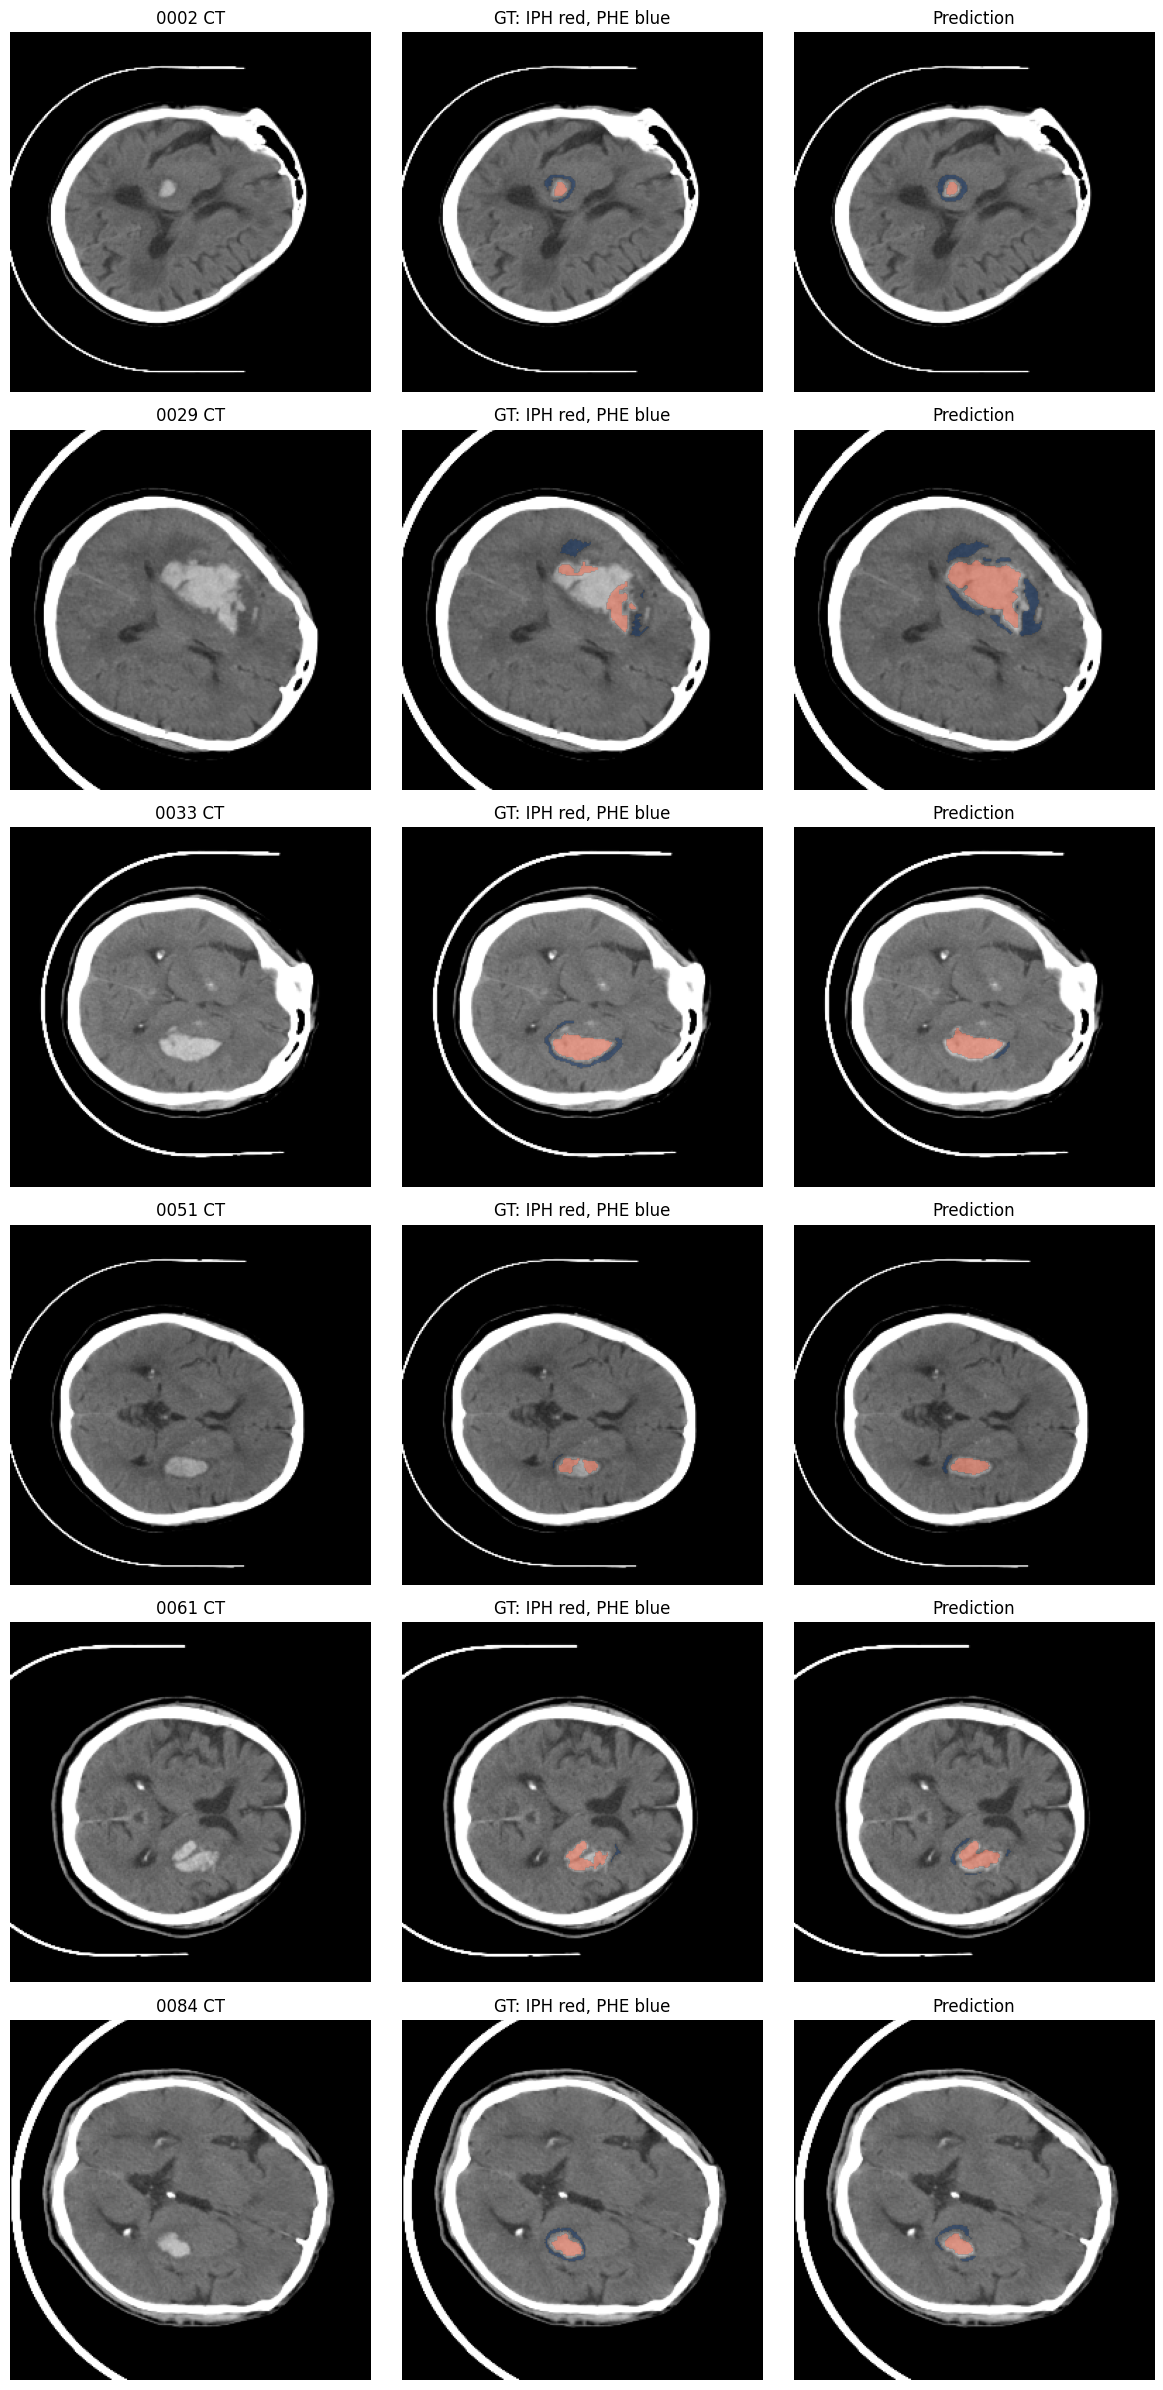

In [13]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE and CFG.run_final_eval:
    if "eval_model" not in globals() or eval_model is None:
        eval_model, used_ckpt = load_best_joint_model()
    if "phe_eval_model" not in globals():
        phe_eval_model, used_phe_ckpt = load_best_phe_model()
    if "tuned_thresholds" not in globals():
        tuned_thresholds = (float(CFG.foreground_threshold), float(CFG.foreground_threshold))
    if "tuned_phe_fusion_weight" not in globals():
        tuned_phe_fusion_weight = 0.0

    if eval_model is not None:
        volume_parts = []
        slice_parts = []
        qualitative_cases = []
        use_specialist = bool(CFG.use_phe_specialist_fusion) and phe_eval_model is not None

        for _, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="test volumes"):
            joint_prob, spacing = predict_joint_probabilities(eval_model, row)
            phe_prob = None
            if use_specialist:
                phe_prob, _ = predict_phe_specialist_probability(phe_eval_model, row)
            target, _, iph_source = load_target_for_row(row)
            pred = prob_to_label_volume(joint_prob, tuned_thresholds, spacing, phe_prob=phe_prob, phe_weight=tuned_phe_fusion_weight)

            if CFG.save_probability_npz:
                save_kwargs = {
                    "joint_prob": joint_prob.astype(np.float16),
                    "threshold_iph": np.float32(tuned_thresholds[0]),
                    "threshold_phe": np.float32(tuned_thresholds[1]),
                    "phe_fusion_weight": np.float32(tuned_phe_fusion_weight),
                }
                if phe_prob is not None:
                    save_kwargs["phe_specialist_prob"] = phe_prob.astype(np.float16)
                np.savez_compressed(PRED_DIR / f"{row['scan_id']}_prob_fusion_multiclass.npz", **save_kwargs)

            volume_parts.append(evaluate_volume_multiclass(row["scan_id"], pred, target, spacing, iph_source))

            s_all = evaluate_slice_multiclass(row["scan_id"], pred, target, spacing, positive_gt_only=False)
            s_pos = evaluate_slice_multiclass(row["scan_id"], pred, target, spacing, positive_gt_only=True)
            s_all["slice_set"] = "all_slices_empty_empty_nan"
            s_pos["slice_set"] = "positive_gt_only"
            slice_parts.extend([s_all, s_pos])

            if len(qualitative_cases) < 6:
                image, _, _ = load_nifti(Path(row["img_path"]))
                z = largest_label_slice(target)
                x_small = make_25d_multiwindow_stack(image, z, image_size=256)
                gt_small = resize_2d(target[:, :, z].astype(np.uint8), 256, order=0)
                pred_small = resize_2d(pred[:, :, z].astype(np.uint8), 256, order=0)
                qualitative_cases.append((row["scan_id"], x_small[len(CFG.slice_offsets) // 2, 0], gt_small, pred_small))

        volume_df = pd.concat(volume_parts, ignore_index=True)
        slice_df = pd.concat(slice_parts, ignore_index=True)
        volume_df.to_csv(TABLE_DIR / "3dff_test_volume_metrics.csv", index=False)
        slice_df.to_csv(TABLE_DIR / "3dff_test_slice_metrics.csv", index=False)

        main_volume_df = volume_df[volume_df["gt_positive"]].copy()
        volume_summary_main = summarize_metrics(
            main_volume_df,
            "3dff:test_volume_gt_positive",
            cols=["dsc", "jaccard", "precision", "recall", "hd95_mm", "hd_mm", "assd_mm", "nsd_1mm", "rvd", "rvd_signed", "volume_abs_error_ml"],
        )
        volume_summary_all = summarize_metrics(
            volume_df,
            "3dff:test_volume_all_cases_empty_empty_nan",
            cols=["dsc", "jaccard", "precision", "recall", "hd95_mm", "hd_mm", "assd_mm", "nsd_1mm", "rvd", "rvd_signed", "volume_abs_error_ml"],
        )

        extra_rows = []
        for class_name, part in volume_df.groupby("class_name"):
            pos = part[part["gt_positive"]]
            extra_rows.extend([
                {"group": "3dff:test_volume_gt_positive", "class_name": class_name, "metric": "volume_rmse_ml", "mean": float(np.sqrt(pos["volume_sq_error_ml2"].mean())) if len(pos) else np.nan, "std": np.nan, "median": np.nan, "n": len(pos), "n_inf": 0},
                {"group": "3dff:test_volume_gt_positive", "class_name": class_name, "metric": "volume_r2", "mean": r2_score_np(pos["target_volume_ml"], pos["pred_volume_ml"]) if len(pos) else np.nan, "std": np.nan, "median": np.nan, "n": len(pos), "n_inf": 0},
                {"group": "3dff:test_volume_all_cases_empty_empty_nan", "class_name": class_name, "metric": "case_detection_rate", "mean": pd.to_numeric(pos["detected"], errors="coerce").mean() if len(pos) else np.nan, "std": np.nan, "median": np.nan, "n": len(pos), "n_inf": 0},
                {"group": "3dff:test_volume_all_cases_empty_empty_nan", "class_name": class_name, "metric": "empty_case_fp_rate", "mean": pd.to_numeric(part.loc[~part["gt_positive"], "false_positive_case"], errors="coerce").mean(), "std": np.nan, "median": np.nan, "n": int((~part["gt_positive"]).sum()), "n_inf": 0},
            ])
        volume_summary = pd.concat([volume_summary_main, volume_summary_all, pd.DataFrame(extra_rows)], ignore_index=True)
        volume_summary.to_csv(TABLE_DIR / "3dff_test_volume_summary.csv", index=False)

        slice_summary = pd.concat([
            summarize_metrics(
                part,
                f"3dff:test_slice:{slice_set}",
                cols=["dice", "jaccard", "precision", "recall", "hd95_mm", "hd_mm"],
            )
            for slice_set, part in slice_df.groupby("slice_set")
        ], ignore_index=True)
        slice_summary.to_csv(TABLE_DIR / "3dff_test_slice_summary.csv", index=False)

        print("Final fusion params:", {"IPH th": tuned_thresholds[0], "PHE th": tuned_thresholds[1], "PHE fusion": tuned_phe_fusion_weight})
        display(volume_summary)
        display(slice_summary)

        if len(qualitative_cases):
            fig, axes = plt.subplots(len(qualitative_cases), 3, figsize=(12, 4 * len(qualitative_cases)))
            if len(qualitative_cases) == 1:
                axes = np.expand_dims(axes, axis=0)
            for i, (scan_id, img, gt, pred) in enumerate(qualitative_cases):
                axes[i, 0].imshow(img, cmap="gray")
                axes[i, 0].set_title(f"{scan_id} CT")
                axes[i, 1].imshow(img, cmap="gray")
                axes[i, 1].imshow(np.ma.masked_where(gt != 1, gt), cmap="Reds", alpha=0.50, vmin=0, vmax=2)
                axes[i, 1].imshow(np.ma.masked_where(gt != 2, gt), cmap="Blues", alpha=0.45, vmin=0, vmax=2)
                axes[i, 1].set_title("GT: IPH red, PHE blue")
                axes[i, 2].imshow(img, cmap="gray")
                axes[i, 2].imshow(np.ma.masked_where(pred != 1, pred), cmap="Reds", alpha=0.50, vmin=0, vmax=2)
                axes[i, 2].imshow(np.ma.masked_where(pred != 2, pred), cmap="Blues", alpha=0.45, vmin=0, vmax=2)
                axes[i, 2].set_title("Prediction")
                for j in range(3):
                    axes[i, j].axis("off")
            plt.tight_layout()
            plt.savefig(FIG_DIR / "3dff_test_qualitative_cases.png", dpi=160, bbox_inches="tight")
            plt.show()
    else:
        print("No joint model checkpoint found.")
else:
    print("Final eval skipped.")

## 13. Paper reporting protocol


In [14]:
protocol = {
    "primary_task": "3D multi-class lesion segmentation on NCCT: background, IPH, PHE (02-11 enhanced)",
    "main_metric_table": str(TABLE_DIR / "3dff_test_volume_summary.csv"),
    "main_metrics": [
        "DSC / Dice, case-level 3D, gt-positive cases only",
        "Jaccard / IoU, case-level 3D, gt-positive cases only",
        "HD95 in mm, computed with NIfTI voxel spacing",
        "ASSD in mm, computed with NIfTI voxel spacing",
        "NSD at 1 mm tolerance",
        "precision, recall, RVD, volume absolute error in ml",
        "PHE-only pretraining before joint refined-pseudo IPH/PHE training",
        "PHE-specialist probability fusion with class-specific threshold tuning",
        "train-heavy 99/10/11 split and hybrid fixed-HU/local-Otsu pseudo IPH",
        "PESE-guided hematoma-similarity slice prior for 3DFF fusion",
        "soft PHE post-processing with fallback against pseudo-IPH errors",
        "local filesystem data loading from the project workspace",
        "enhanced train-heavy run; do not compare directly with old-split experiments",
    ],
    "empty_case_policy": "Main lesion metrics exclude empty GT cases and store empty-empty as NaN; detection and empty-case FP rates are reported separately.",
    "iph_label_warning": "If CFG.true_iph_mask_dir is None, IPH metrics are against paper-guided HU/Otsu/PHE-derived pseudo labels, not manual IPH labels.",
    "do_not_mix": [
        "Do not compare positive-slice Dice with 3D volume Dice.",
        "Do not compare pseudo-IPH DSC with manual-IPH DSC without saying pseudo-label.",
        "Do not report all-case Dice if many empty cases are included unless empty handling is explicit.",
    ],
}

with open(LOG_DIR / "3dff_reporting_protocol.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, ensure_ascii=False, indent=2)

print(json.dumps(protocol, ensure_ascii=False, indent=2))


{
  "primary_task": "3D multi-class lesion segmentation on NCCT: background, IPH, PHE (02-11 enhanced)",
  "main_metric_table": "D:\\Thuy_Loi\\Nam_3\\CT_xuathuyetnao\\outputs_02_11_enhanced_pese_guided_3dff_refined_pseudo_iph_phe_25d_segmentation\\tables\\3dff_test_volume_summary.csv",
  "main_metrics": [
    "DSC / Dice, case-level 3D, gt-positive cases only",
    "Jaccard / IoU, case-level 3D, gt-positive cases only",
    "HD95 in mm, computed with NIfTI voxel spacing",
    "ASSD in mm, computed with NIfTI voxel spacing",
    "NSD at 1 mm tolerance",
    "precision, recall, RVD, volume absolute error in ml",
    "PHE-only pretraining before joint refined-pseudo IPH/PHE training",
    "PHE-specialist probability fusion with class-specific threshold tuning",
    "train-heavy 99/10/11 split and hybrid fixed-HU/local-Otsu pseudo IPH",
    "PESE-guided hematoma-similarity slice prior for 3DFF fusion",
    "soft PHE post-processing with fallback against pseudo-IPH errors",
    "local files